# Human Spinal Cord Single Sample

- **Creator**: Jiamao Liu (<liujiamao@stu.xmu.edu.cn>)
- **Date of Creation:** 27.05.2025
- **Date of Last Modification:** 27.05.2025 (Jiamao Liu; <liujiamao@stu.xmu.edu.cn>)

- In order to run this notebook, a trained model needs to be stored under ```/artifacts/{dataset}/models/{model_label}/{load_timestamp}```.
    - dataset: ```stereo_seq_spinal_cord_gwall```
    - model_label: ```integration```
    - load_timestamp: ```27052025_044245```
- Run this notebook in the nichecompass-reproducibility environment, installable from ```('/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/envs/environment.yaml')```.

## 1. Setup

### 1.1 Import Libraries

In [4]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:32'
os.environ["CUDA_VISIBLE_DEVICES"] = "1" # Set the environment variable to use GPU 1
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/utils")
import argparse
import gc
import os
import random
import shutil
import warnings
import logging
from datetime import datetime

import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import mlflow
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scipy.stats as stats
import seaborn as sns
import squidpy as sq
import torch
from matplotlib import gridspec
from matplotlib.pyplot import rc_context
from pywaffle import Waffle
from sklearn.preprocessing import MinMaxScaler

from nichecompass.models import NicheCompass
from nichecompass.utils import (add_gps_from_gp_dict_to_adata,
                                compute_communication_gp_network,
                                visualize_communication_gp_network,
                                create_new_color_dict,
                                extract_gp_dict_from_mebocost_ms_interactions,
                                extract_gp_dict_from_nichenet_lrt_interactions,
                                extract_gp_dict_from_omnipath_lr_interactions,
                                filter_and_combine_gp_dict_gps_v2,
                                generate_enriched_gp_info_plots,
                                aggregate_obsp_matrix_per_cell_type,
                                create_cell_type_chord_plot_from_df
                                )

from analysis_utils import (add_cell_type_latent_cluster_emphasis,
                            add_sub_cell_type,
                            compute_cell_type_latent_clusters,
                            generate_gp_info_plots,
                            plot_category_in_latent_and_physical_space,
                            plot_cell_type_latent_clusters,
                            plot_latent,
                            plot_physical_latent_for_cell_types,
                            sankey,
                            store_top_gps_summary)

plt.rcParams["pdf.fonttype"] = 42  
plt.rcParams["font.family"] = "sans-serif" 
device = torch.device("cuda:1")

/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  File "/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/urllib3/connectionpool.py", line 404, in _make_request
    self._validate_conn(conn)
  File "/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/urllib3/connectionpool.py", line 1061, in _validate_conn
    conn.connect()
  File "/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/urllib3/connection.py", line 419, in connect
    self.sock = ssl_wrap_socket(
  File "/cluster

### 1.2 Define Parameters

In [2]:
### Dataset ###
dataset = "stereo_seq_spinal_cord_gwall"
species = "human"
batches = ["gw6", "gw7-2", "gw9", "gw10", "gw12", "gw16", "gw17-1"]
spatial_key = "spatial"
n_neighbors = 4

### Model ###
# AnnData keys
counts_key = "counts"
adj_key = "spatial_connectivities"
cat_covariates_keys = ["batch"]
gp_names_key = "nichecompass_gp_names"
active_gp_names_key = "nichecompass_active_gp_names"
gp_targets_mask_key = "nichecompass_gp_targets"
gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
gp_sources_mask_key = "nichecompass_gp_sources"
gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"
latent_key = "nichecompass_latent"

# Architecture
cat_covariates_embeds_injection = ["gene_expr_decoder"]
cat_covariates_embeds_nums = [500]
cat_covariates_no_edges = [True]
conv_layer_encoder = "gcnconv" # change to "gatv2conv" if enough compute and memory
active_gp_thresh_ratio = 0.01

# Trainer
n_epochs = 100
n_epochs_all_gps = 25
lr = 0.001
lambda_edge_recon = 500000.
lambda_gene_expr_recon = 300.
lambda_l1_masked = 0. # prior GP  regularization
lambda_l1_addon = 30. # de novo GP regularization
edge_batch_size = 1024 # increase if more memory available or decrease to save memory
n_sampled_neighbors = 4
use_cuda_if_available = True

### Analysis ###
cell_type_key = "broad_cell_type"
latent_leiden_resolution = 0.3
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
sample_key = "batch"
spot_size = 30
differential_gp_test_results_key = "nichecompass_differential_gp_test_results"

### 1.3 Run Notebook Setup

In [3]:
# Ignore future warnings and user warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [4]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")
current_timestamp

'27052025_070214'

In [3]:
current_timestamp = "27052025_044245"

### 1.4 Configure Paths and Create Directories

In [6]:
# Define paths
ga_data_folder_path = "/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/datasets/ga_data"
gp_data_folder_path = "/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/datasets/gp_data"
so_data_folder_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/Smooth/H5AD"
omnipath_lr_network_file_path = f"{gp_data_folder_path}/omnipath_lr_network.csv"
collectri_tf_network_file_path = f"{gp_data_folder_path}/collectri_tf_network_{species}.csv"
nichenet_lr_network_file_path = f"{gp_data_folder_path}/nichenet_lr_network_v2_{species}.csv"
nichenet_ligand_target_matrix_file_path = f"{gp_data_folder_path}/nichenet_ligand_target_matrix_v2_{species}.csv"
mebocost_enzyme_sensor_interactions_folder_path = f"{gp_data_folder_path}/metabolite_enzyme_sensor_gps"
gene_orthologs_mapping_file_path = f"{ga_data_folder_path}/human_mouse_gene_orthologs.csv"

figure_folder_path = f"../../artifacts/{dataset}/figures/single_sample/{current_timestamp}"
model_folder_path = f"../../artifacts/{dataset}/models/single_sample/{current_timestamp}"
result_folder_path = f"../../artifacts/{dataset}/results/single_sample/{current_timestamp}"

# Create required directories
os.makedirs(so_data_folder_path, exist_ok=True)
os.makedirs(model_folder_path, exist_ok=True)
os.makedirs(figure_folder_path, exist_ok=True)
os.makedirs(result_folder_path, exist_ok=True)

## 2. Prepare Model Training

### 2.1 Create Prior Knowledge Gene Program (GP) Mask
- NicheCompass expects a prior GP mask as input, which it will use to make its latent feature space interpretable (through linear masked decoders). 
- The user can provide a custom GP mask to NicheCompass based on the biological question of interest.
- As a default, here we create a GP mask based on three databases of prior knowledge of inter- and intracellular interaction pathways:
    - OmniPath (Ligand-Receptor GPs)
    - MEBOCOST (Enzyme-Sensor GPs)
    - NicheNet (Combined Interaction GPs)

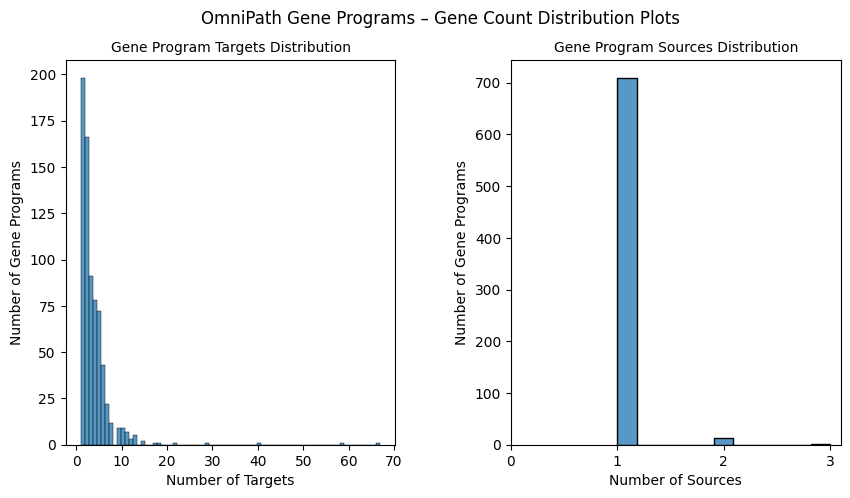

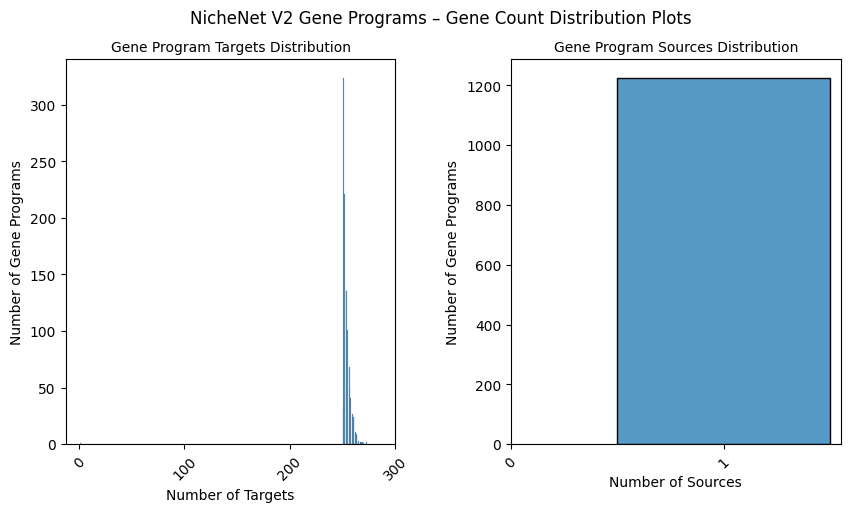

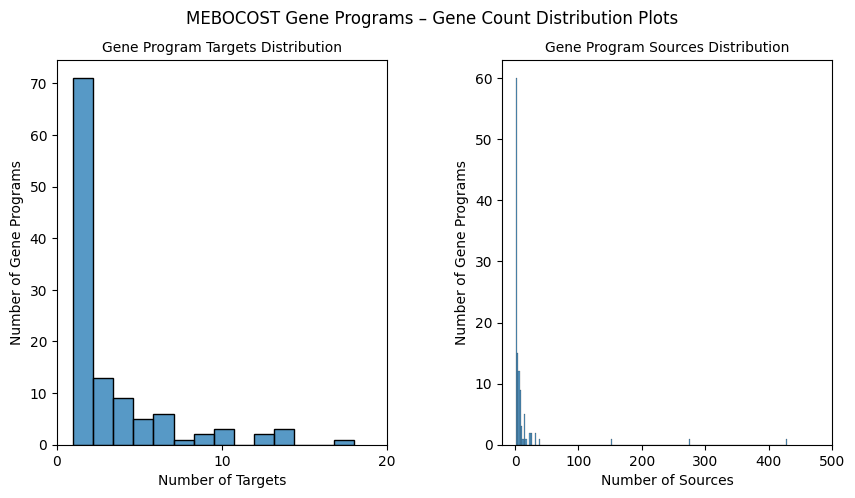

Combining ACE2_ligand_receptor_GP and ACE2_ligand_receptor_target_gene_GP.
Combining ADCYAP1_ligand_receptor_GP and ADCYAP1_ligand_receptor_target_gene_GP.
Combining ADGRE5_ligand_receptor_GP and ADGRE5_ligand_receptor_target_gene_GP.
Combining ADIPOQ_ligand_receptor_GP and ADIPOQ_ligand_receptor_target_gene_GP.
Combining ADM_ligand_receptor_GP and ADM_ligand_receptor_target_gene_GP.
Combining ADM2_ligand_receptor_GP and ADM2_ligand_receptor_target_gene_GP.
Combining AGRP_ligand_receptor_GP and AGRP_ligand_receptor_target_gene_GP.
Combining AGT_ligand_receptor_GP and AGT_ligand_receptor_target_gene_GP.
Combining ALCAM_ligand_receptor_GP and ALCAM_ligand_receptor_target_gene_GP.
Combining ALKAL1_ligand_receptor_GP and ALKAL1_ligand_receptor_target_gene_GP.
Combining ALKAL2_ligand_receptor_GP and ALKAL2_ligand_receptor_target_gene_GP.
Combining AMBN_ligand_receptor_GP and AMBN_ligand_receptor_target_gene_GP.
Combining AMELX_ligand_receptor_GP and AMELX_ligand_receptor_target_gene_GP.
Com

In [6]:
# Retrieve OmniPath GPs (source: ligand genes; target: receptor genes)
omnipath_gp_dict = extract_gp_dict_from_omnipath_lr_interactions(
    species=species,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=omnipath_lr_network_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True,
    gp_gene_count_distributions_save_path=f"{figure_folder_path}" \
                                           "/omnipath_gp_gene_count_distributions.pdf")

# Display example OmniPath GP
omnipath_gp_names = list(omnipath_gp_dict.keys())
random.shuffle(omnipath_gp_names)
omnipath_gp_name = omnipath_gp_names[0]
#print(f"{omnipath_gp_name}: {omnipath_gp_dict[omnipath_gp_name]}")

# Retrieve NicheNet GPs (source: ligand genes; target: receptor genes, target genes)
nichenet_gp_dict = extract_gp_dict_from_nichenet_lrt_interactions(
    species=species,
    version="v2",
    keep_target_genes_ratio=1.,
    max_n_target_genes_per_gp=250,
    load_from_disk=True,
    save_to_disk=True,
    lr_network_file_path=nichenet_lr_network_file_path,
    ligand_target_matrix_file_path=nichenet_ligand_target_matrix_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True)

# Display example NicheNet GP
nichenet_gp_names = list(nichenet_gp_dict.keys())
random.shuffle(nichenet_gp_names)
nichenet_gp_name = nichenet_gp_names[0]
#print(f"{nichenet_gp_name}: {nichenet_gp_dict[nichenet_gp_name]}")

# Retrieve MEBOCOST GPs (source: enzyme genes; target: sensor genes)
mebocost_gp_dict = extract_gp_dict_from_mebocost_ms_interactions(
    dir_path=mebocost_enzyme_sensor_interactions_folder_path,
    species=species,
    plot_gp_gene_count_distributions=True)

# Display example MEBOCOST GP
mebocost_gp_names = list(mebocost_gp_dict.keys())
random.shuffle(mebocost_gp_names)
mebocost_gp_name = mebocost_gp_names[0]
#print(f"{mebocost_gp_name}: {mebocost_gp_dict[mebocost_gp_name]}")

# Filter and combine GPs
gp_dicts = [omnipath_gp_dict, nichenet_gp_dict, mebocost_gp_dict]
combined_gp_dict = filter_and_combine_gp_dict_gps_v2(
    gp_dicts,
    verbose=True)

### 2.2 Load Data & Compute Spatial Neighbor Graph

- NicheCompass expects a precomputed spatial adjacency matrix stored in 'adata.obsp[adj_key]'.
- The user can customize the spatial neighbor graph construction based on the biological question of interest.
- In the sample integration setting, we will compute a separate spatial adjacency matrix for each sample and combine them as disconnected components.

In [7]:
so_data_folder_path

'/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/Smooth/H5AD'

In [28]:
adata_batch_list = []
print("Processing all batches...")
for batch in batches:
    print(f"Processing batch {batch}...")
    print("Loading data...")
    adata_batch = sc.read_h5ad(
        f"{so_data_folder_path}/SeuratObj_{batch}.h5ad")
    adata_batch.obs[sample_key] = batch
    adata_batch.layers['counts'] = adata_batch.X.copy()
    adata_batch.obsm['spatial'] = adata_batch.obsm['X_cod']

    print("Computing spatial neighborhood graph...\n")
    # Compute (separate) spatial neighborhood graphs
    sq.gr.spatial_neighbors(adata_batch,
                            coord_type="generic",
                            spatial_key=spatial_key,
                            n_neighs=n_neighbors)
    
    # Make adjacency matrix symmetric
    adata_batch.obsp[adj_key] = (
        adata_batch.obsp[adj_key].maximum(
            adata_batch.obsp[adj_key].T))
    adata_batch_list.append(adata_batch)

adata_all = ad.concat(adata_batch_list, join="inner")
sc.pp.normalize_total(adata_all)
sc.pp.log1p(adata_all)
sc.pp.highly_variable_genes(adata_all, n_top_genes=8000, batch_key="batch")
adata_all = adata_all[:, adata_all.var.highly_variable]

# Combine spatial neighborhood graphs as disconnected components
batch_connectivities = []
len_before_batch = 0
for i in range(len(adata_batch_list)):
    if i == 0: # first batch
        after_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[0].shape[0],
            (adata_all.shape[0] -
            adata_batch_list[0].shape[0])))
        batch_connectivities.append(sp.hstack(
            (adata_batch_list[0].obsp[adj_key],
            after_batch_connectivities_extension)))
    elif i == (len(adata_batch_list) - 1): # last batch
        before_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0],
            (adata_all.shape[0] -
            adata_batch_list[i].shape[0])))
        batch_connectivities.append(sp.hstack(
            (before_batch_connectivities_extension,
            adata_batch_list[i].obsp[adj_key])))
    else: # middle batches
        before_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0], len_before_batch))
        after_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0],
            (adata_all.shape[0] -
            adata_batch_list[i].shape[0] -
            len_before_batch)))
        batch_connectivities.append(sp.hstack(
            (before_batch_connectivities_extension,
            adata_batch_list[i].obsp[adj_key],
            after_batch_connectivities_extension)))
    len_before_batch += adata_batch_list[i].shape[0]
adata_all.obsp[adj_key] = sp.vstack(batch_connectivities)

Processing all batches...
Processing batch gw6...
Loading data...
Computing spatial neighborhood graph...

Processing batch gw7-2...
Loading data...
Computing spatial neighborhood graph...

Processing batch gw9...
Loading data...
Computing spatial neighborhood graph...

Processing batch gw10...
Loading data...
Computing spatial neighborhood graph...

Processing batch gw12...
Loading data...
Computing spatial neighborhood graph...

Processing batch gw16...
Loading data...
Computing spatial neighborhood graph...

Processing batch gw17-1...
Loading data...
Computing spatial neighborhood graph...



### 2.3 Add GP Mask to Data

In [29]:
# Add the GP dictionary as binary masks to the adata
add_gps_from_gp_dict_to_adata(
    gp_dict=combined_gp_dict,
    adata=adata_all,
    gp_targets_mask_key=gp_targets_mask_key,
    gp_targets_categories_mask_key=gp_targets_categories_mask_key,
    gp_sources_mask_key=gp_sources_mask_key,
    gp_sources_categories_mask_key=gp_sources_categories_mask_key,
    gp_names_key=gp_names_key,
    min_genes_per_gp=2,
    min_source_genes_per_gp=1,
    min_target_genes_per_gp=1,
    max_genes_per_gp=None,
    max_source_genes_per_gp=None,
    max_target_genes_per_gp=None)

### 2.4 Explore Data (annotation need!!!)

In [9]:
adata_all

AnnData object with n_obs × n_vars = 82157 × 10000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'nichecompass_sources_categories_label_encoder', 'nichecompass_targets_categories_label_encoder', 'nichecompass_source_genes_idx', 'nichecompass_target_genes_idx', 'nichecompass_genes_idx', 'nichecompass_gp_names'
    obsm: 'X_cod', 'spatial'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_targets', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets_categories'
    layers: 'counts'
    obsp: 'spatial_connectivities'

In [ ]:
samples = adata_all.obs[sample_key].unique().tolist()

## 3. Train Model

### 3.1 Initialize, Train & Save Model

In [31]:
# Initialize model
model = NicheCompass(adata_all,
                     counts_key=counts_key,
                     adj_key=adj_key,
                     cat_covariates_embeds_injection=cat_covariates_embeds_injection,
                     cat_covariates_keys=cat_covariates_keys,
                     cat_covariates_no_edges=cat_covariates_no_edges,
                     cat_covariates_embeds_nums=cat_covariates_embeds_nums,
                     gp_names_key=gp_names_key,
                     active_gp_names_key=active_gp_names_key,
                     gp_targets_mask_key=gp_targets_mask_key,
                     gp_targets_categories_mask_key=gp_targets_categories_mask_key,
                     gp_sources_mask_key=gp_sources_mask_key,
                     gp_sources_categories_mask_key=gp_sources_categories_mask_key,
                     latent_key=latent_key,
                     conv_layer_encoder=conv_layer_encoder,
                     active_gp_thresh_ratio=active_gp_thresh_ratio)

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
CATEGORICAL COVARIATES EMBEDDINGS INJECTION -> ['gene_expr_decoder']
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 8000, n_cat_covariates_embed_input: 0, n_hidden: 594, n_latent: 494, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 494, n_addon_gp_input: 100, n_cat_covariates_embed_input: 500, n_output: 8000
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 494, n_addon_gp_input: 100, n_cat_covariates_embed_input: 500, n_output: 8000


In [32]:
# Train model
model.train(n_epochs=n_epochs,
            n_epochs_all_gps=n_epochs_all_gps,
            lr=lr,
            lambda_edge_recon=lambda_edge_recon,
            lambda_gene_expr_recon=lambda_gene_expr_recon,
            lambda_l1_masked=lambda_l1_masked,
            edge_batch_size=edge_batch_size,
            n_sampled_neighbors=n_sampled_neighbors,
            use_cuda_if_available=use_cuda_if_available,
            verbose=False)


--- INITIALIZING TRAINER ---
Number of training nodes: 74641
Number of validation nodes: 8293
Number of training edges: 150534
Number of validation edges: 16725
Edge batch size: 1024
Node batch size: None

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% train_global_loss: 1166714.7796; train_optim_loss: 1166714.7796; val_global_loss: 736423.6103; val_optim_loss: 736423.6103
Epoch 2/100 |--------------------| 2.0% train_global_loss: 731116.9489; train_optim_loss: 731116.9489; val_global_loss: 729133.8382; val_optim_loss: 729133.8382
Epoch 3/100 |--------------------| 3.0% train_global_loss: 724950.3066; train_optim_loss: 724950.3066; val_global_loss: 722828.9963; val_optim_loss: 722828.9963
Epoch 4/100 |--------------------| 4.0% train_global_loss: 719963.6951; train_optim_loss: 719963.6951; val_global_loss: 718393.6213; val_optim_loss: 718393.6213
Epoch 5/100 |█-------------------| 5.0% train_global_loss: 716211.6102; train_optim_loss: 716211.6102; val_global_loss: 7141

In [34]:
# Compute latent neighbor graph
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)

# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [37]:
# Save trained model
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata.h5ad")

## 4. Analysis

In [3]:
load_timestamp = '27052025_044245'
# load_timestamp = current_timestamp # uncomment if you trained the model in this notebook

figure_folder_path = f"../../artifacts/{dataset}/figures/single_sample/{load_timestamp}"
model_folder_path = f"../../artifacts/{dataset}/models/single_sample/{load_timestamp}"
result_folder_path = f"../../artifacts/{dataset}/results/single_sample/{load_timestamp}"

os.makedirs(figure_folder_path, exist_ok=True)

In [5]:
# Load trained model
model = NicheCompass.load(dir_path=model_folder_path,
                          adata=None,
                          adata_file_name="adata.h5ad",
                          gp_names_key=gp_names_key)

/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
CATEGORICAL COVARIATES EMBEDDINGS INJECTION -> ['gene_expr_decoder']
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 8000, n_cat_covariates_embed_input: 0, n_hidden: 594, n_latent: 494, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 494, n_addon_gp_input: 100, n_cat_covariates_embed_input: 500, n_output: 8000
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 494, n_addon_gp_input: 100, n_cat_covariates_embed_input: 500, n_output: 8000


### 4.1 Visualize NicheCompass Latent GP Space

Let's look at the preservation of cell type annotations in the latent GP space. Note that the goal of NicheCompass is not a separation of cell types but rather to identify spatially consistent cell niches.

In [25]:
cell_type_colors = {
    'Microglia': '#8FBC8F',       # Moss green - marker color for microglia
    'Neural_progenitor': '#FFD700', # Standard gold - canonical color for proliferative cells
    'Excitatory': '#4682B4',      # Steel blue - reference color for excitatory neurons
    'Inhibitory': '#CD5C5C',      # Terracotta red - standard contrast color for GABAergic neurons
    'Motor_neuron': '#9370DB',    # Lilac - unified color for motor system cells
    'APC': '#2E8B57',             # Sea green - characteristic color for glial progenitor cells
    'Trip': '#FF8C00',            # Amber orange - warning color for rare cell types
    'Ependymal': '#7AC5CD',       # Glacier blue - color associated with ependymal dynamics
    'Unknown': '#A9A99A',         # Basalt gray - neutral color for unannotated cells
    '-1': '#DCDCDC'               # Mist white - technical noise/background signal
}

In [ ]:
# Create plot of cell type annotations in physical and latent space
groups = None
save_fig = True
file_path = f"{figure_folder_path}/" \
            "cell_types_latent_physical_space.pdf"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"Cell Types " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[cell_type_key],
           groups=groups,
           palette=cell_type_colors,
           title=f"Cell Types in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=[cell_type_key],
                  groups=groups,
                  palette=cell_type_colors,
                  spot_size=spot_size,
                  title=f"Cell Types in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

### 4.2 Identify Niches

We compute Leiden clustering of the NicheCompass latent GP space to identify spatially consistent cell niches.

In [6]:
model.adata

AnnData object with n_obs × n_vars = 82157 × 10000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'batch', 'latent_leiden_0.3'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'latent_leiden_0.3_colors', 'leiden', 'log1p', 'nichecompass_active_gp_names', 'nichecompass_genes_idx', 'nichecompass_gp_names', 'nichecompass_latent', 'nichecompass_source_genes_idx', 'nichecompass_sources_categories_label_encoder', 'nichecompass_target_genes_idx', 'nichecompass_targets_categories_label_encoder', 'umap'
    obsm: 'X_cod', 'X_umap', 'nichecompass_latent', 'spatial'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets', 'nichecompass_gp_targets_categories'
    layers: 'counts'
    obsp: 'nichecompass_latent_connectivities', 'nichecompass_latent_distances', 'spatial_connectivities'

In [33]:
# Define the resolutions to test
latent_leiden_resolutions = [0.355,0.356,0.357,0.358,0.359,0.361,0.362,0.363,0.364,0.365]

for latent_leiden_resolution in latent_leiden_resolutions:
    # Compute latent Leiden clustering with current resolution
    sc.tl.leiden(adata=model.adata,
                 resolution=latent_leiden_resolution,
                 key_added=latent_cluster_key,
                 neighbors_key=latent_key)
    
    # Create new color dictionary for the clusters
    latent_cluster_colors = create_new_color_dict(
        adata=model.adata,
        cat_key=latent_cluster_key)

    samples = model.adata.obs[sample_key].unique()
    
    # Create plot of latent cluster / niche annotations in physical and latent space
    groups = None  # set this to a specific cluster for easy visualization, e.g. ["17"]
    save_fig = True
    file_path = f"{figure_folder_path}/" \
                f"res_{latent_leiden_resolution}_" \
                "niches_latent_physical_space.pdf"

    fig = plt.figure(figsize=(12, 14))
    title = fig.suptitle(t=f"NicheCompass Niches " \
                           f"(Resolution: {latent_leiden_resolution}) " \
                           "in Latent and Physical Space",
                         y=0.96,
                         x=0.55,
                         fontsize=20)
    spec1 = gridspec.GridSpec(ncols=1,
                              nrows=2,
                              width_ratios=[1],
                              height_ratios=[3, 2])
    spec2 = gridspec.GridSpec(ncols=len(samples),
                              nrows=2,
                              width_ratios=[1] * len(samples),
                              height_ratios=[3, 2])
    axs = []
    axs.append(fig.add_subplot(spec1[0]))
    sc.pl.umap(adata=model.adata,
               color=[latent_cluster_key],
               groups=groups,
               palette=latent_cluster_colors,
               title=f"Niches in Latent Space",
               ax=axs[0],
               show=False)
    for idx, sample in enumerate(samples):
        axs.append(fig.add_subplot(spec2[len(samples) + idx]))
        sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                      color=[latent_cluster_key],
                      groups=groups,
                      palette=latent_cluster_colors,
                      spot_size=spot_size,
                      title=f"Niches in Physical Space \n"
                            f"(Sample: {sample})",
                      legend_loc=None,
                      ax=axs[idx+1],
                      show=False)

    # Create and position shared legend
    handles, labels = axs[0].get_legend_handles_labels()
    lgd = fig.legend(handles,
                     labels,
                     loc="center left",
                     bbox_to_anchor=(0.98, 0.5))
    axs[0].get_legend().remove()

    # Adjust, save and display plot
    plt.subplots_adjust(wspace=0.2, hspace=0.25)
    if save_fig:
        fig.savefig(file_path,
                    bbox_extra_artists=(lgd, title),
                    bbox_inches="tight",
                    format="pdf")
    plt.close(fig)  # Close the figure to free memory

In [6]:
latent_leiden_resolution = 0.36
sc.tl.leiden(adata=model.adata,
                 resolution=latent_leiden_resolution,
                 key_added=latent_cluster_key,
                 neighbors_key=latent_key)

In [7]:
batch_colors = create_new_color_dict( 
    adata=model.adata,
    cat_key=cat_covariates_keys[0])

In [10]:
samples = model.adata.obs[sample_key].unique().tolist()

/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid se

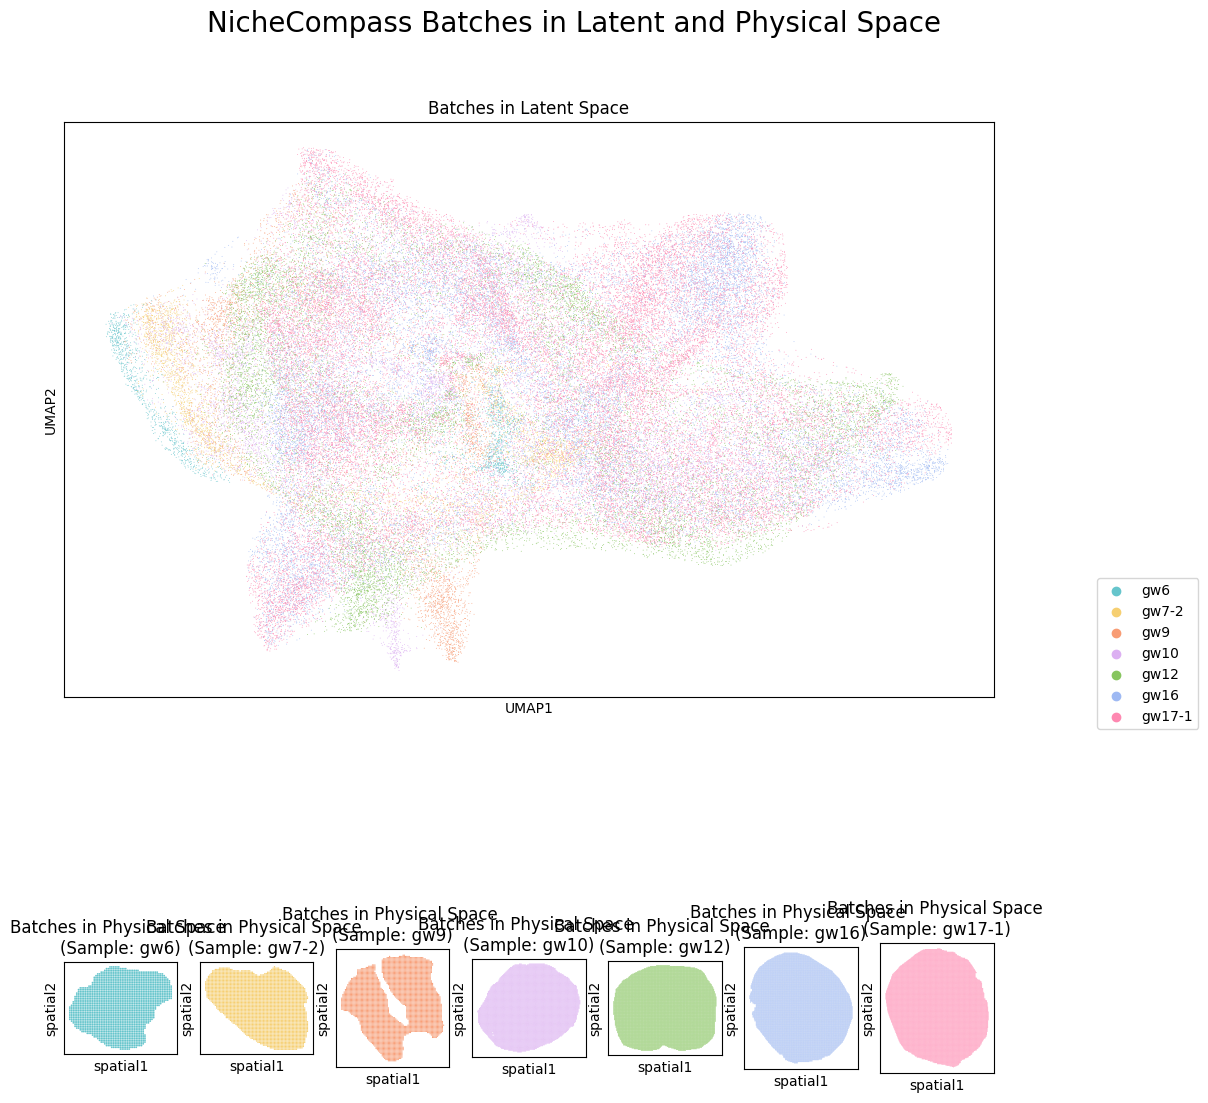

In [12]:
# Create plot of batch annotations in physical and latent space
groups = None
save_fig = True
file_path = f"{figure_folder_path}/" \
            "batches_latent_physical_space.pdf"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"NicheCompass Batches " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[cat_covariates_keys[0]],
           groups=groups,
           palette=batch_colors,
           title=f"Batches in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=[cat_covariates_keys[0]],
                  groups=groups,
                  palette=batch_colors,
                  spot_size=spot_size,
                  title=f"Batches in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

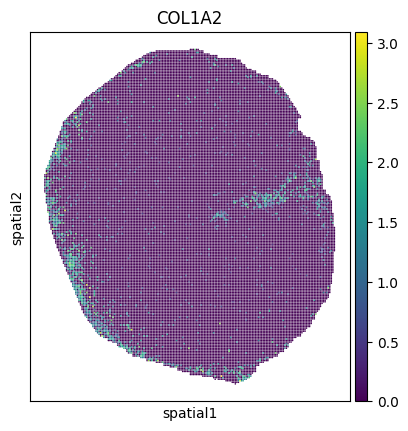

In [24]:
sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=['COL1A2'],
                  spot_size=30,
            )

### 4.3 Characterize Niches

Now we will characterize the identified cell niches.

#### 4.3.1 Differential GPs

Now we can test which GPs are differentially expressed in a niche. To this end, we will perform "one-vs-rest" differential GP testing, i.e all niches (```selected_cats = None```) are tested against all other niches (```comparison_cats = "rest"```). However, differential GP testing can also be performed in the following ways:
- Set ```selected_cats = ["0"]``` to perform differential GP testing for a specific niche only, in this case niche "0".
- Set ```comparison_cats = ["2"]``` to perform differential GP testing against niche "2" as opposed to against all other niches.

We choose an absolute log bayes factor threshold of 2.3 to determine strongly enriched GPs (see https://en.wikipedia.org/wiki/Bayes_factor).

In [37]:
# Check number of active GPs
active_gps = model.get_active_gps()
print(f"Number of total gene programs: {len(model.adata.uns[gp_names_key])}.")
print(f"Number of active gene programs: {len(active_gps)}.")

Number of total gene programs: 594.
Number of active gene programs: 498.


In [38]:
# Display example active GPs
gp_summary_df = model.get_gp_summary()
gp_summary_df[gp_summary_df["gp_active"] == True].head()

,gp_name,all_gp_idx,gp_active,active_gp_idx,n_source_genes,n_non_zero_source_genes,n_target_genes,n_non_zero_target_genes,gp_source_genes,gp_target_genes,gp_source_genes_weights,gp_target_genes_weights,gp_source_genes_importances,gp_target_genes_importances
0,AFDN_ligand_receptor_GP,0,True,0,1,1,4,4,[AFDN],"[NRXN3, EPHB3, EPHA7, NECTIN2]",[0.0563],"[1.26, -0.4171, 0.2519, -0.0085]",[0.0283],"[0.6319, 0.2092, 0.1263, 0.0043]"
1,ARF6_ligand_receptor_GP,1,True,1,1,1,3,3,[ARF6],"[PLD1, PIP5K1A, MAPK1]",[-0.2743],"[0.4437, 0.1072, 0.0076]",[0.3294],"[0.5328, 0.1288, 0.0091]"
2,COMPLEX:EGFR_ERBB3_ligand_receptor_GP,2,True,2,2,2,1,1,"[ERBB3, EGFR]",[PIK3R1],"[-1.3403, 0.7198]",[0.071],"[0.6289, 0.3378]",[0.0333]
3,COMPLEX:IL6R_IL6ST_ligand_receptor_GP,3,True,3,2,2,2,2,"[IL6ST, IL6R]","[JAK2, JAK1]","[-1.8401, -0.0384]","[0.1348, 0.0359]","[0.898, 0.0187]","[0.0658, 0.0175]"
4,COMPLEX:LAMA1_LAMB1_LAMC1_ligand_receptor_GP,4,True,4,3,3,2,2,"[LAMC1, LAMB1, LAMA1]","[ITGA6, ITGB1]","[-1.7419, -1.512, -0.8122]","[-0.2215, 0.0816]","[0.3987, 0.346, 0.1859]","[0.0507, 0.0187]"


In [39]:
# Set parameters for differential gp testing
selected_cats = None
comparison_cats = "rest"
title = f"NicheCompass Strongly Enriched Niche GPs"
log_bayes_factor_thresh = 2.3
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"/log_bayes_factor_{log_bayes_factor_thresh}" \
             "_niches_enriched_gps_heatmap.pdf"

In [40]:
# Run differential gp testing
enriched_gps = model.run_differential_gp_tests(
    cat_key=latent_cluster_key,
    selected_cats=selected_cats,
    comparison_cats=comparison_cats,
    log_bayes_factor_thresh=log_bayes_factor_thresh)

In [41]:
# Results are stored in a df in the adata object
differential_gp_test_results_frame = model.adata.uns[differential_gp_test_results_key]
differential_gp_test_results_frame

,category,gene_program,p_h0,p_h1,log_bayes_factor
0,4,Add-on_31_GP,0.991161,0.008839,4.719663
1,3,Add-on_72_GP,0.019459,0.980541,-3.919783
2,4,PTPN11_ligand_receptor_GP,0.978655,0.021345,3.825364
3,1,LMAN1_ligand_receptor_GP,0.972133,0.027867,3.552033
4,3,INHBA_combined_GP,0.028117,0.971883,-3.542861
...,...,...,...,...,...
138,3,CD14_ligand_receptor_target_gene_GP,0.909583,0.090417,2.308555
139,3,gamma-Aminobutyric acid_metabolite_enzyme_sens...,0.090499,0.909501,-2.307560
140,1,MANSC1_ligand_receptor_target_gene_GP,0.090673,0.909327,-2.305444
141,6,CFAP54_ligand_receptor_target_gene_GP,0.090919,0.909081,-2.302465


In [42]:
# Group by category and select top three rows by p_h0 in each group
top_rows_per_category = differential_gp_test_results_frame.groupby('category').apply(
    lambda group: group.nlargest(5, 'p_h0')
).reset_index(drop=True)

top_rows_per_category['gene_program']

/tmp/ipykernel_717920/2323021327.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_rows_per_category = differential_gp_test_results_frame.groupby('category').apply(


0                                    FLRT3_combined_GP
1                ZDHHC5_ligand_receptor_target_gene_GP
2                                     WNT3_combined_GP
3                                      NPY_combined_GP
4                  RECK_ligand_receptor_target_gene_GP
5                             LMAN1_ligand_receptor_GP
6                                  ANGPTL1_combined_GP
7                     Heme_metabolite_enzyme_sensor_GP
8                                     BST2_combined_GP
9                  SDK2_ligand_receptor_target_gene_GP
10             Glutathione_metabolite_enzyme_sensor_GP
11                                  SEMA7A_combined_GP
12                                        Add-on_18_GP
13                 CDH6_ligand_receptor_target_gene_GP
14                                    TGFA_combined_GP
15             SERPING1_ligand_receptor_target_gene_GP
16                                    CCL2_combined_GP
17                                   TGFB2_combined_GP
18        

In [43]:
# Visualize GP activities of enriched GPs across niches
df = model.adata.obs[[latent_cluster_key] + enriched_gps].groupby(latent_cluster_key).mean()

scaler = MinMaxScaler()
normalized_columns = scaler.fit_transform(df)
normalized_df = pd.DataFrame(normalized_columns, columns=df.columns)
normalized_df.index = df.index

In [45]:
top5 = normalized_df[top_rows_per_category['gene_program'].to_list()]
top5.to_csv(f"{result_folder_path}/top5_enriched_gps_per_niche.csv")

#### 4.3.2 Ncihe annotation

In [ ]:
# Calculate mean nCount_Spatial for each leiden cluster
mean_counts = model.adata.obs.groupby('latent_leiden_0.3')['nCount_Spatial'].mean()
mean_counts

In [46]:
# annotation from 4.3.2 Differential GPs!!! calculate and back here.
niche_annotation_dict = {
    "0":"Dorsal_Horn", 
    "1":"Cavity",
    "2":"MN_Horn", 
    "3":"Meninge",
    "4":"White_Matter",
    "5":"Intermediate_Gray",
    "6":"VZ",
    "7":"Ventral_Horn",
    "8":"Early_Horn/Lateral_Horn",
    "9":"Early_White_Matter"}

model.adata.obs["niche"] = model.adata.obs[latent_cluster_key].map(niche_annotation_dict)

In [135]:
latent_niche_colors = {
    'Dorsal_Horn': "#BF3131",  
    'Cavity': "#8ca0d7",     
    'MN_Horn': '#9370DB', 
    'Meninge': "#b47846",    
    'White_Matter': '#4682B4',    
    'Intermediate_Gray': "#226f54",      
    'VZ': '#EF8746',      
    'Ventral_Horn': "#2E8B57",   
    'Early_Horn/Lateral_Horn': "#FFC73D",
    'Early_White_Matter': "#1988E3B7",
    '-1': '#DCDCDC'          
}

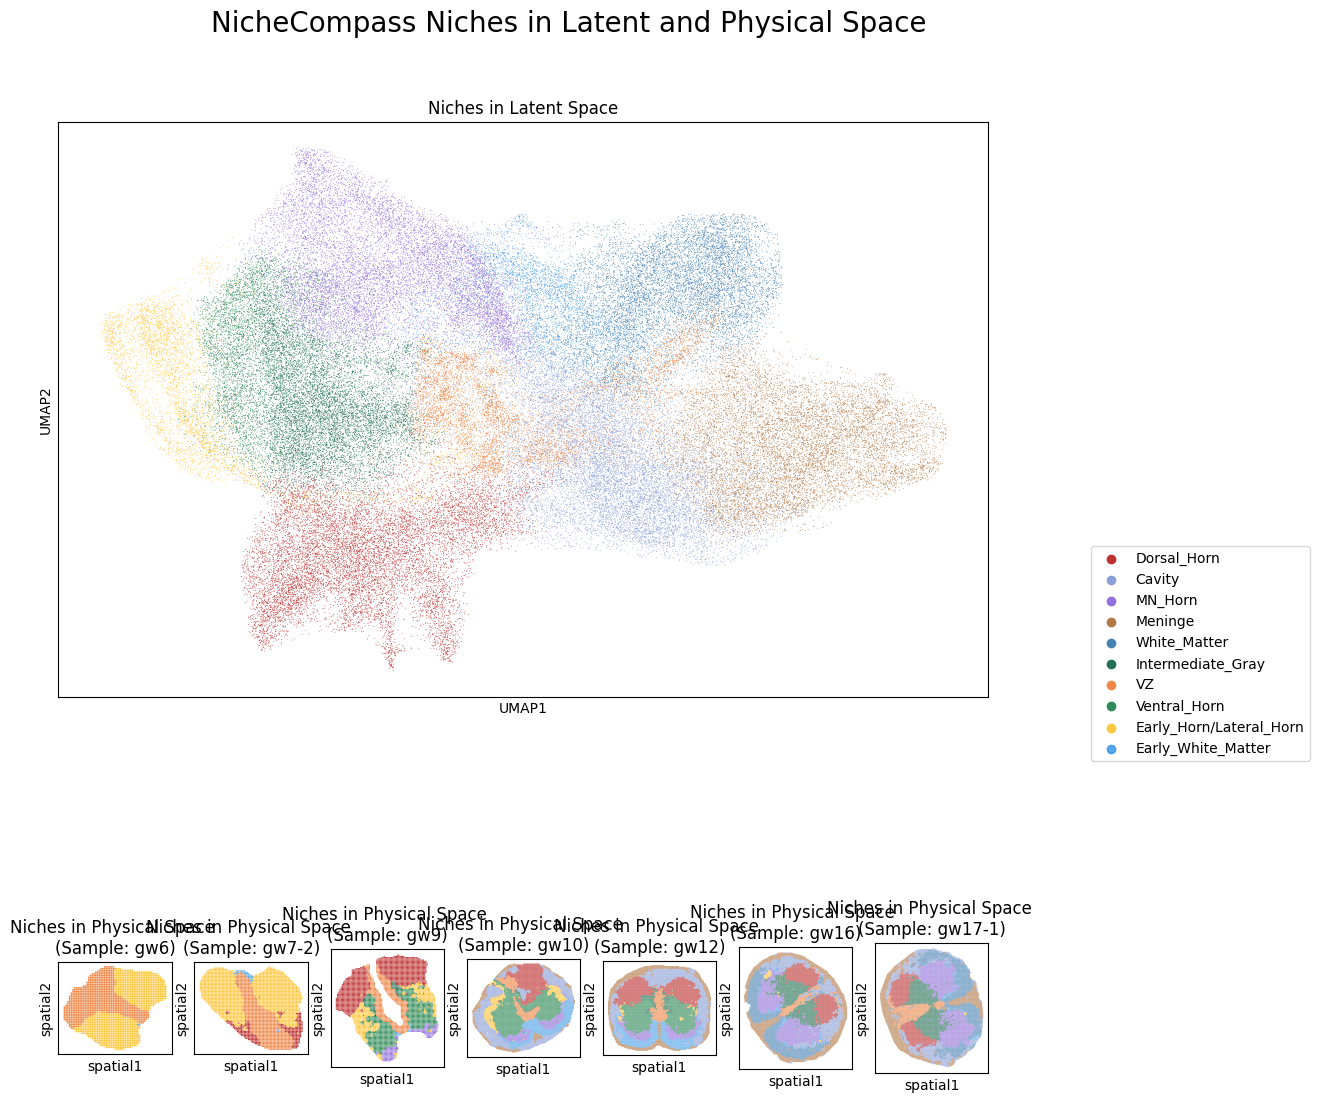

In [136]:
# Create plot of latent cluster / niche annotations in physical and latent space
groups = None # set this to a specific cluster for easy visualization, e.g. ["17"]
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            "niches_latent_physical_space.pdf"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"NicheCompass Niches " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=["niche"],
           groups=groups,
           palette=latent_niche_colors,
           title=f"Niches in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=["niche"],
                  groups=groups,
                  palette=latent_niche_colors,
                  spot_size=spot_size,
                  title=f"Niches in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

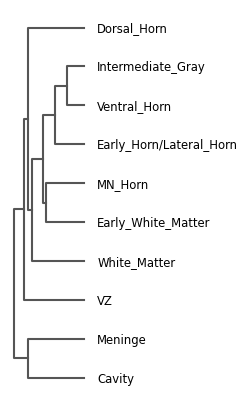

In [182]:
# dendrogram
sc.tl.dendrogram(adata=model.adata,
                 use_rep="nichecompass_latent",
                 linkage_method="single",
                 optimal_ordering = True,
                 groupby="niche")

fig, (ax) = plt.subplots(1, 1, figsize=(1, 5))
sc.pl.dendrogram(
    adata=model.adata,
    groupby="niche",
    orientation="left",
    ax=ax)
plt.show()

file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            "dendrogram_nichecompass_latent.pdf"
fig.savefig(file_path)

In [165]:
# Calculate mean nCount_Spatial for each leiden cluster
mean_counts = model.adata.obs.groupby('niche')['nCount_Spatial'].mean()
mean_counts

niche
Dorsal_Horn                 790.905746
Cavity                      258.472664
MN_Horn                     545.877494
Meninge                     367.471216
White_Matter                430.224923
Intermediate_Gray           729.284230
VZ                          788.879981
Ventral_Horn               1347.639493
Early_Horn/Lateral_Horn     919.864681
Early_White_Matter          492.641307
Name: nCount_Spatial, dtype: float64

#### 4.3.3 Niche Composition

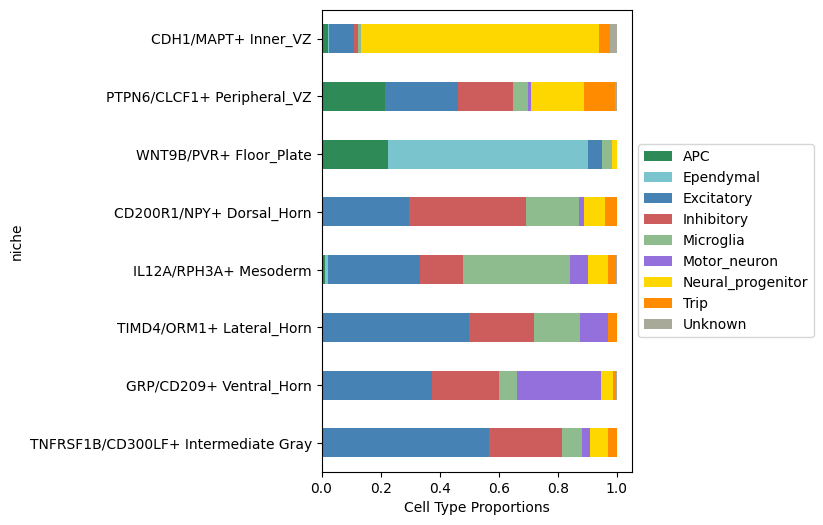

In [26]:
# scaled niche_cell_type_proportions
tmp = pd.crosstab(model.adata.obs["niche"], model.adata.obs[cell_type_key], normalize='index')
tmp = tmp.reindex(model.adata.uns["dendrogram_niche"]["categories_ordered"][::])
ax = tmp.plot.barh(color=cell_type_colors, stacked=True, figsize=(4, 6)).legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xlabel("Cell Type Proportions")
plt.savefig(f"{figure_folder_path}/niche_cell_type_proportions.pdf", bbox_inches='tight')

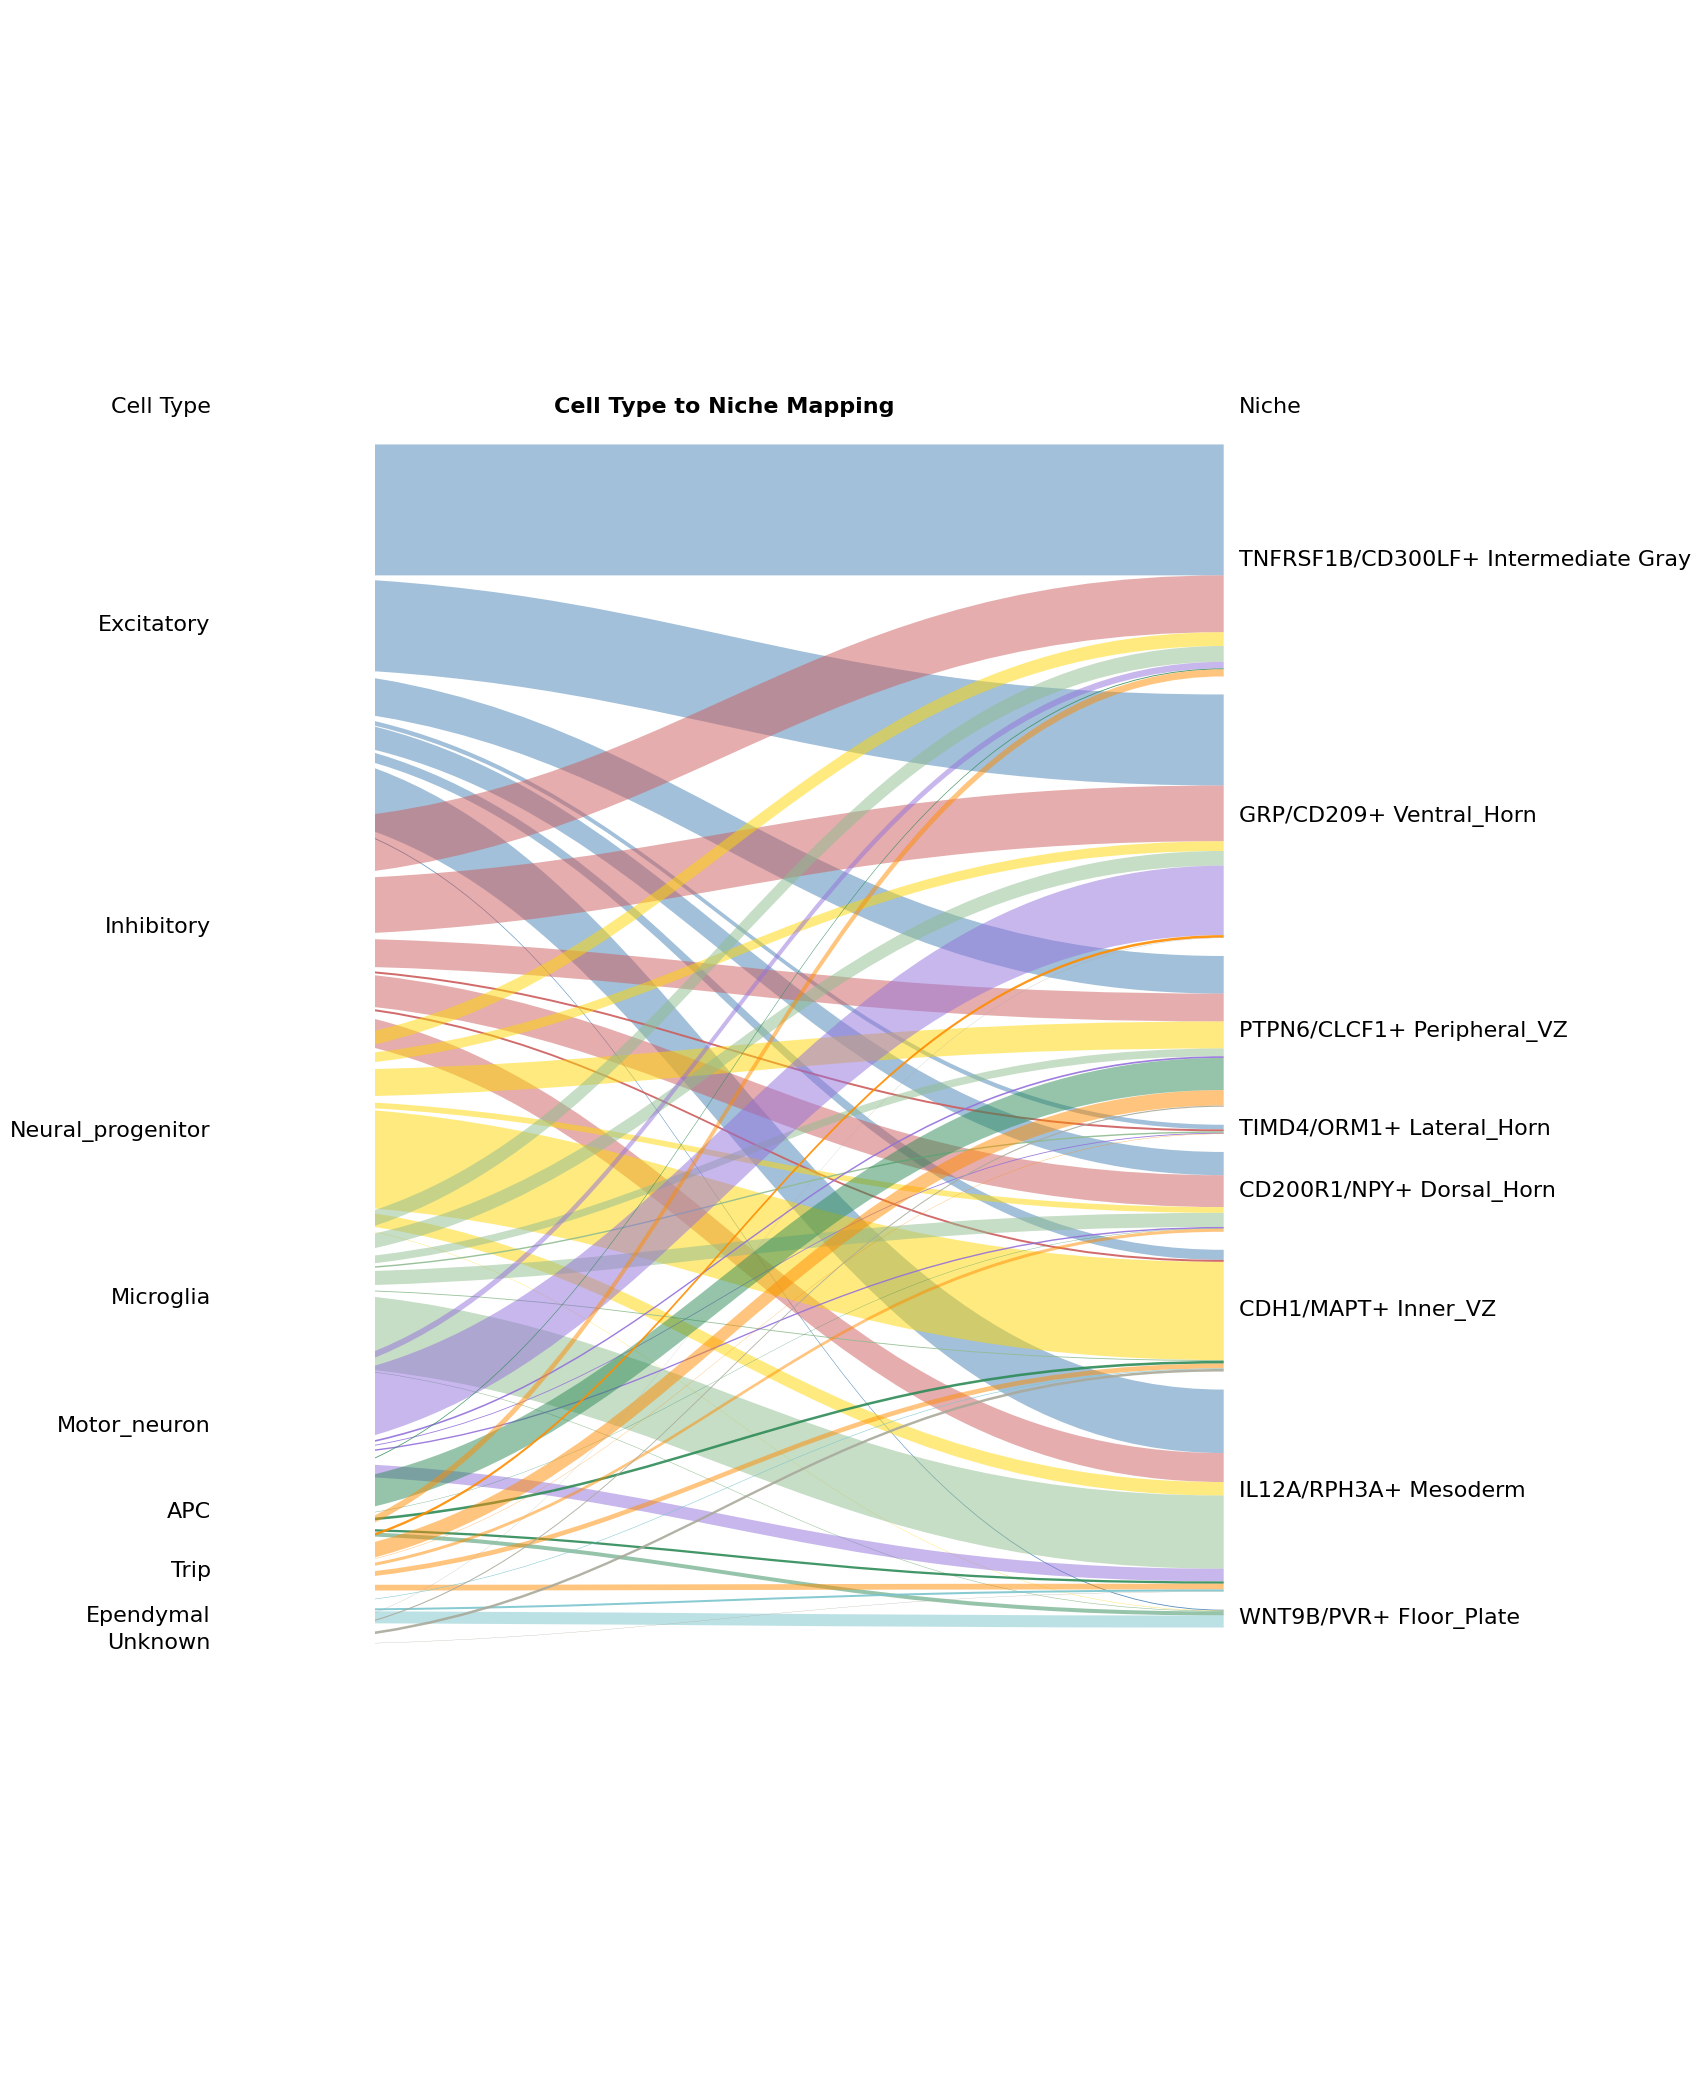

In [27]:
# sankey plot
fig, ax = plt.subplots(figsize=(17, 21))
sankey(
    x=model.adata.obs[cell_type_key],
    y=model.adata.obs["niche"],
    title="Cell Type to Niche Mapping",
    title_left="Cell Type",
    title_right="Niche",
    ax=ax,
    fontsize="16",  # "xx-small",
    #left_order=model.adata.obs[cell_type_key].unique().tolist(),
    colors=cell_type_colors,
    alpha=0.5)
plt.tight_layout()
plt.savefig(f"{figure_folder_path}/sankey_cell_type_to_niche.pdf")
plt.show()

#### 4.3.4 GP activities

In [138]:
# Visualize GP activities of enriched GPs across niches
df = model.adata.obs[["niche"] + enriched_gps].groupby("niche").mean()
scaler = MinMaxScaler()
normalized_columns = scaler.fit_transform(df)
normalized_df = pd.DataFrame(normalized_columns, columns=df.columns)
normalized_df.index = df.index
normalized_df

,Add-on_31_GP,Add-on_72_GP,PTPN11_ligand_receptor_GP,LMAN1_ligand_receptor_GP,INHBA_combined_GP,VSIG10_ligand_receptor_target_gene_GP,SERPING1_ligand_receptor_target_gene_GP,ANGPTL1_combined_GP,Heme_metabolite_enzyme_sensor_GP,BST2_combined_GP,...,ADAM23_ligand_receptor_target_gene_GP,LGALS8_ligand_receptor_GP,RECK_ligand_receptor_target_gene_GP,L-Lysine_metabolite_enzyme_sensor_GP,VSTM1_ligand_receptor_target_gene_GP,CD14_ligand_receptor_target_gene_GP,gamma-Aminobutyric acid_metabolite_enzyme_sensor_GP,MANSC1_ligand_receptor_target_gene_GP,CFAP54_ligand_receptor_target_gene_GP,SPARC_ligand_receptor_target_gene_GP
niche,,,,,,,,,,,,,,,,,,,,,
Dorsal_Horn,0.105739,0.842767,0.259214,0.197341,0.786080,0.935607,0.210435,0.243552,0.103011,0.331670,...,0.000000,1.000000,0.000000,0.451954,0.993061,0.107583,0.923784,0.504056,0.777561,0.033212
Cavity,0.363794,0.398565,0.156270,1.000000,0.493939,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.412595,0.908766,0.924366,0.000000,0.916400,0.567781,0.554738,0.000000,0.807562,0.546751
MN_Horn,0.211960,0.831524,0.080534,0.194389,0.739705,0.704859,0.182393,0.324470,0.204040,0.157351,...,0.754192,0.581915,1.000000,0.299841,0.729483,0.226129,0.944047,0.390228,0.431930,0.136670
Meninge,0.077688,0.000000,0.179074,0.000000,0.000000,0.855079,1.000000,0.103430,0.012615,0.000000,...,0.802056,0.216470,0.878945,0.818181,0.316244,1.000000,0.000000,0.909301,1.000000,1.000000
White_Matter,1.000000,0.554755,1.000000,0.146239,0.768321,1.000000,0.223125,0.000000,0.000000,0.132309,...,0.990082,0.649493,0.438716,0.752917,0.452840,0.392227,0.477986,0.673844,0.559779,0.301165
Intermediate_Gray,0.000000,0.972284,0.000000,0.191424,0.911019,0.712498,0.410366,0.070578,0.172131,0.052635,...,0.598651,0.176578,0.766364,0.989988,0.138669,0.096117,1.000000,1.000000,0.485637,0.082769
VZ,0.366310,0.454218,0.233826,0.169219,1.000000,0.587703,0.415583,0.264406,0.309510,0.415007,...,0.911567,0.658611,0.876821,0.693036,0.730050,0.000000,0.664707,0.646385,0.000000,0.469500
Ventral_Horn,0.311670,1.000000,0.311805,0.267208,0.874563,0.718236,0.304403,0.116881,0.205200,0.026629,...,1.000000,0.000000,0.947890,1.000000,0.000000,0.087584,0.837589,0.906858,0.628548,0.000000
Early_Horn/Lateral_Horn,0.353734,0.816701,0.358948,0.388332,0.552042,0.779345,0.186207,0.200090,0.253307,0.225093,...,0.736010,0.494590,0.642258,0.571081,0.397349,0.337135,0.769881,0.618310,0.958394,0.135278


In [183]:
# Custom sorting order
custom_order = [
    "Dorsal_Horn",
    "Intermediate_Gray",
    "Ventral_Horn",
    "Early_Horn/Lateral_Horn",
    "MN_Horn",
    "Early_White_Matter",
    "White_Matter",
    "VZ",
    "Meninge",
    "Cavity"
]

# Reorder index by custom order
normalized_df = normalized_df.reindex(custom_order)
normalized_df

,Add-on_31_GP,Add-on_72_GP,PTPN11_ligand_receptor_GP,LMAN1_ligand_receptor_GP,INHBA_combined_GP,VSIG10_ligand_receptor_target_gene_GP,SERPING1_ligand_receptor_target_gene_GP,ANGPTL1_combined_GP,Heme_metabolite_enzyme_sensor_GP,BST2_combined_GP,...,ADAM23_ligand_receptor_target_gene_GP,LGALS8_ligand_receptor_GP,RECK_ligand_receptor_target_gene_GP,L-Lysine_metabolite_enzyme_sensor_GP,VSTM1_ligand_receptor_target_gene_GP,CD14_ligand_receptor_target_gene_GP,gamma-Aminobutyric acid_metabolite_enzyme_sensor_GP,MANSC1_ligand_receptor_target_gene_GP,CFAP54_ligand_receptor_target_gene_GP,SPARC_ligand_receptor_target_gene_GP
niche,,,,,,,,,,,,,,,,,,,,,
Dorsal_Horn,0.105739,0.842767,0.259214,0.197341,0.786080,0.935607,0.210435,0.243552,0.103011,0.331670,...,0.000000,1.000000,0.000000,0.451954,0.993061,0.107583,0.923784,0.504056,0.777561,0.033212
Intermediate_Gray,0.000000,0.972284,0.000000,0.191424,0.911019,0.712498,0.410366,0.070578,0.172131,0.052635,...,0.598651,0.176578,0.766364,0.989988,0.138669,0.096117,1.000000,1.000000,0.485637,0.082769
Ventral_Horn,0.311670,1.000000,0.311805,0.267208,0.874563,0.718236,0.304403,0.116881,0.205200,0.026629,...,1.000000,0.000000,0.947890,1.000000,0.000000,0.087584,0.837589,0.906858,0.628548,0.000000
Early_Horn/Lateral_Horn,0.353734,0.816701,0.358948,0.388332,0.552042,0.779345,0.186207,0.200090,0.253307,0.225093,...,0.736010,0.494590,0.642258,0.571081,0.397349,0.337135,0.769881,0.618310,0.958394,0.135278
MN_Horn,0.211960,0.831524,0.080534,0.194389,0.739705,0.704859,0.182393,0.324470,0.204040,0.157351,...,0.754192,0.581915,1.000000,0.299841,0.729483,0.226129,0.944047,0.390228,0.431930,0.136670
Early_White_Matter,0.481011,0.566433,0.291402,0.236480,0.628655,0.664012,0.143764,0.342965,0.305004,0.354162,...,0.763081,0.883319,0.685561,0.252348,1.000000,0.412411,0.676481,0.242724,0.213619,0.445154
White_Matter,1.000000,0.554755,1.000000,0.146239,0.768321,1.000000,0.223125,0.000000,0.000000,0.132309,...,0.990082,0.649493,0.438716,0.752917,0.452840,0.392227,0.477986,0.673844,0.559779,0.301165
VZ,0.366310,0.454218,0.233826,0.169219,1.000000,0.587703,0.415583,0.264406,0.309510,0.415007,...,0.911567,0.658611,0.876821,0.693036,0.730050,0.000000,0.664707,0.646385,0.000000,0.469500
Meninge,0.077688,0.000000,0.179074,0.000000,0.000000,0.855079,1.000000,0.103430,0.012615,0.000000,...,0.802056,0.216470,0.878945,0.818181,0.316244,1.000000,0.000000,0.909301,1.000000,1.000000


In [184]:
# data from above
differential_gp_test_results_frame

,category,gene_program,p_h0,p_h1,log_bayes_factor
0,4,Add-on_31_GP,0.991161,0.008839,4.719663
1,3,Add-on_72_GP,0.019459,0.980541,-3.919783
2,4,PTPN11_ligand_receptor_GP,0.978655,0.021345,3.825364
3,1,LMAN1_ligand_receptor_GP,0.972133,0.027867,3.552033
4,3,INHBA_combined_GP,0.028117,0.971883,-3.542861
...,...,...,...,...,...
138,3,CD14_ligand_receptor_target_gene_GP,0.909583,0.090417,2.308555
139,3,gamma-Aminobutyric acid_metabolite_enzyme_sens...,0.090499,0.909501,-2.307560
140,1,MANSC1_ligand_receptor_target_gene_GP,0.090673,0.909327,-2.305444
141,6,CFAP54_ligand_receptor_target_gene_GP,0.090919,0.909081,-2.302465


In [185]:
differential_gp_test_results_frame['category'] = differential_gp_test_results_frame['category'].map(niche_annotation_dict)
differential_gp_test_results_frame

,category,gene_program,p_h0,p_h1,log_bayes_factor
0,White_Matter,Add-on_31_GP,0.991161,0.008839,4.719663
1,Meninge,Add-on_72_GP,0.019459,0.980541,-3.919783
2,White_Matter,PTPN11_ligand_receptor_GP,0.978655,0.021345,3.825364
3,Cavity,LMAN1_ligand_receptor_GP,0.972133,0.027867,3.552033
4,Meninge,INHBA_combined_GP,0.028117,0.971883,-3.542861
...,...,...,...,...,...
138,Meninge,CD14_ligand_receptor_target_gene_GP,0.909583,0.090417,2.308555
139,Meninge,gamma-Aminobutyric acid_metabolite_enzyme_sens...,0.090499,0.909501,-2.307560
140,Cavity,MANSC1_ligand_receptor_target_gene_GP,0.090673,0.909327,-2.305444
141,VZ,CFAP54_ligand_receptor_target_gene_GP,0.090919,0.909081,-2.302465


In [186]:
# Convert category column to ordered categorical type
differential_gp_test_results_frame['category'] = pd.Categorical(differential_gp_test_results_frame['category'], 
                               categories=custom_order,
                               ordered=True)

# Sort by category, then by descending p_h0
differential_gp = differential_gp_test_results_frame.sort_values(by=['category', 'p_h0'],
                          ascending=[True, False],
                          kind='mergesort')  # Keep sorting stable
differential_gp

,category,gene_program,p_h0,p_h1,log_bayes_factor
38,Dorsal_Horn,FLRT3_combined_GP,0.956546,0.043454,3.091637
74,Dorsal_Horn,ZDHHC5_ligand_receptor_target_gene_GP,0.938219,0.061781,2.720393
78,Dorsal_Horn,WNT3_combined_GP,0.935936,0.064064,2.681663
96,Dorsal_Horn,NPY_combined_GP,0.927133,0.072867,2.543463
135,Dorsal_Horn,RECK_ligand_receptor_target_gene_GP,0.089362,0.910638,-2.321445
...,...,...,...,...,...
29,Cavity,Stearic acid_metabolite_enzyme_sensor_GP,0.041200,0.958800,-3.147239
27,Cavity,PGF_combined_GP,0.040657,0.959343,-3.161066
26,Cavity,EDA_combined_GP,0.040506,0.959494,-3.164962
15,Cavity,IFNAR2_ligand_receptor_GP,0.035766,0.964234,-3.294323


In [187]:
# Group by category and select top three rows by p_h0 in each group
top_rows_per_category = differential_gp.groupby('category').apply(
    lambda group: group.nlargest(5, 'p_h0')
).reset_index(drop=True)

top_rows_per_category['gene_program']

/tmp/ipykernel_717920/2243529472.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_rows_per_category = differential_gp.groupby('category').apply(


0                                    FLRT3_combined_GP
1                ZDHHC5_ligand_receptor_target_gene_GP
2                                     WNT3_combined_GP
3                                      NPY_combined_GP
4                  RECK_ligand_receptor_target_gene_GP
5                 VSTM1_ligand_receptor_target_gene_GP
6                            LGALS8_ligand_receptor_GP
7                     Iron_metabolite_enzyme_sensor_GP
8     13-cis-Retinoic acid_metabolite_enzyme_sensor_GP
9              Glutathione_metabolite_enzyme_sensor_GP
10                                  SEMA7A_combined_GP
11                                        Add-on_18_GP
12                 CDH6_ligand_receptor_target_gene_GP
13                                    TGFA_combined_GP
14                                        Add-on_31_GP
15                           PTPN11_ligand_receptor_GP
16                                 ANGPTL2_combined_GP
17                  MAG_ligand_receptor_target_gene_GP
18        

In [188]:
top5 = normalized_df[top_rows_per_category['gene_program'].to_list()]
top5

,FLRT3_combined_GP,ZDHHC5_ligand_receptor_target_gene_GP,WNT3_combined_GP,NPY_combined_GP,RECK_ligand_receptor_target_gene_GP,VSTM1_ligand_receptor_target_gene_GP,LGALS8_ligand_receptor_GP,Iron_metabolite_enzyme_sensor_GP,13-cis-Retinoic acid_metabolite_enzyme_sensor_GP,Glutathione_metabolite_enzyme_sensor_GP,...,SERPING1_ligand_receptor_target_gene_GP,CCL2_combined_GP,TGFB2_combined_GP,COL1A2_ligand_receptor_target_gene_GP,IFITM1_ligand_receptor_target_gene_GP,LMAN1_ligand_receptor_GP,ANGPTL1_combined_GP,Heme_metabolite_enzyme_sensor_GP,BST2_combined_GP,SDK2_ligand_receptor_target_gene_GP
niche,,,,,,,,,,,,,,,,,,,,,
Dorsal_Horn,1.000000,1.000000,1.000000,1.000000,0.000000,0.993061,1.000000,0.810564,0.856454,0.000000,...,0.210435,0.000000,0.082610,0.138503,0.165209,0.197341,0.243552,0.103011,0.331670,0.294743
Intermediate_Gray,0.256009,0.511245,0.698688,0.452214,0.766364,0.138669,0.176578,0.097994,0.067937,0.174569,...,0.410366,0.157313,0.100695,0.000000,0.020767,0.191424,0.070578,0.172131,0.052635,0.042010
Ventral_Horn,0.099387,0.402347,0.527813,0.000688,0.947890,0.000000,0.000000,0.000000,0.000000,0.311723,...,0.304403,0.249242,0.000000,0.048537,0.000000,0.267208,0.116881,0.205200,0.026629,0.000000
Early_Horn/Lateral_Horn,0.310273,0.540762,0.396025,0.133136,0.642258,0.397349,0.494590,0.474916,0.509504,0.385271,...,0.186207,0.256575,0.134213,0.181633,0.102020,0.388332,0.200090,0.253307,0.225093,0.181496
MN_Horn,0.126700,0.323596,0.308728,0.012501,1.000000,0.729483,0.581915,0.826963,0.748130,1.000000,...,0.182393,0.157477,0.126892,0.131203,0.036198,0.194389,0.324470,0.204040,0.157351,0.407685
Early_White_Matter,0.402432,0.100852,0.195159,0.144103,0.685561,1.000000,0.883319,1.000000,0.901760,0.794972,...,0.143764,0.205945,0.415588,0.343844,0.296506,0.236480,0.342965,0.305004,0.354162,0.504497
White_Matter,0.525830,0.042767,0.217118,0.000000,0.438716,0.452840,0.649493,0.559826,0.521614,0.149366,...,0.223125,0.125886,0.238991,0.189099,0.303471,0.146239,0.000000,0.000000,0.132309,0.043149
VZ,0.527204,0.000000,0.647328,0.329304,0.876821,0.730050,0.658611,0.500791,0.492720,0.418880,...,0.415583,0.110443,0.435233,0.097580,0.356679,0.169219,0.264406,0.309510,0.415007,0.346949
Meninge,0.000000,0.485203,0.000000,0.126360,0.878945,0.316244,0.216470,0.238238,0.432495,0.172574,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.103430,0.012615,0.000000,0.057411


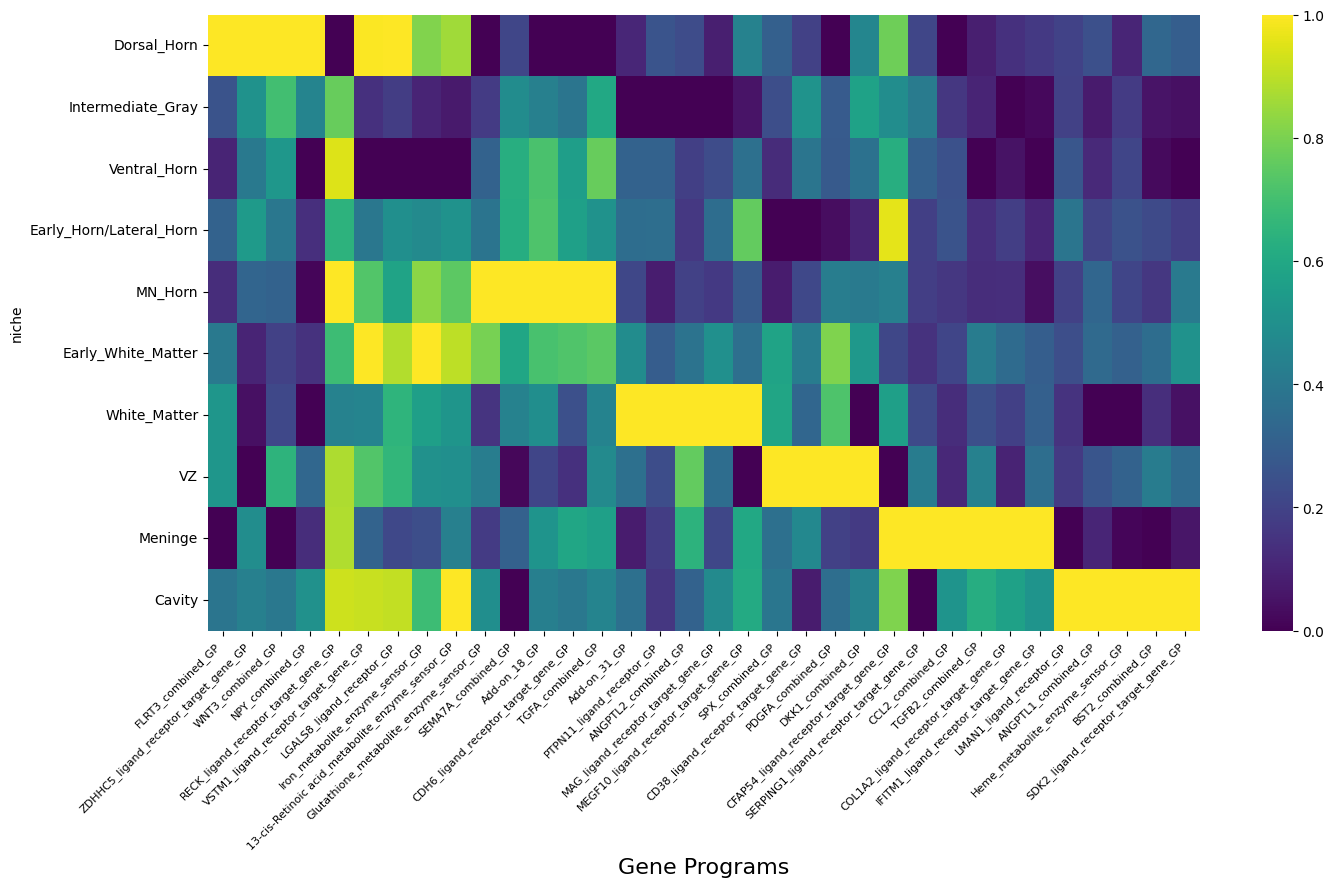

In [189]:

plt.figure(figsize=(16, 8))  # Set the figure size
ax = sns.heatmap(top5,
            cmap='viridis',
            annot=False,
            linewidths=0)
plt.xticks(rotation=45,
           fontsize=8,
           ha="right"
          )
plt.xlabel("Gene Programs", fontsize=16)
plt.savefig(f"{figure_folder_path}/enriched_top5_gps_heatmap.pdf",
            bbox_inches="tight")

In [190]:
# Store gene program summary of enriched gene programs
save_file = True
file_path = f"{figure_folder_path}/" \
            f"/log_bayes_factor_{log_bayes_factor_thresh}_" \
            "niche_enriched_gps_summary.csv"

gp_summary_cols = ["gp_name",
                   "n_source_genes",
                   "n_non_zero_source_genes",
                   "n_target_genes",
                   "n_non_zero_target_genes",
                   "gp_source_genes",
                   "gp_target_genes",
                   "gp_source_genes_importances",
                   "gp_target_genes_importances"]

enriched_gp_summary_df = gp_summary_df[gp_summary_df["gp_name"].isin(enriched_gps)]
cat_dtype = pd.CategoricalDtype(categories=enriched_gps, ordered=True)
enriched_gp_summary_df.loc[:, "gp_name"] = enriched_gp_summary_df["gp_name"].astype(cat_dtype)
enriched_gp_summary_df = enriched_gp_summary_df.sort_values(by="gp_name")
enriched_gp_summary_df = enriched_gp_summary_df[gp_summary_cols]

if save_file:
    enriched_gp_summary_df.to_csv(f"{file_path}")
else:
    display(enriched_gp_summary_df)

Now we will have a look at the GP activities and the log normalized counts of
the most important omics features of the differential GPs.

In [ ]:
plot_label = f"log_bayes_factor_{log_bayes_factor_thresh}_cluster_{selected_cats[0] if selected_cats else 'None'}_vs_rest"
save_figs = True

generate_enriched_gp_info_plots(
    plot_label=plot_label,
    model=model,
    sample_key=sample_key,
    differential_gp_test_results_key=differential_gp_test_results_key,
    cat_key="niche",
    cat_palette=latent_niche_colors,
    n_top_enriched_gp_start_idx=0,
    n_top_enriched_gp_end_idx=10,
    feature_spaces=samples, # ["latent"]
    n_top_genes_per_gp=3,
    save_figs=save_figs,
    figure_folder_path=f"{figure_folder_path}/",
    spot_size=20)

#### 4.3.5 Cell-cell Communication

Now we will use the inferred activity of an enriched combined interaction GP to analyze the involved intercellular interactions.

In [ ]:
# Load trained model
model = NicheCompass.load(dir_path=result_folder_path,
                          adata=None,
                          adata_file_name=f"{dataset}_analysis.h5ad",
                          gp_names_key=gp_names_key)


In [47]:
gp_network_path = f"{figure_folder_path}/gp_network"
os.makedirs(gp_network_path, exist_ok=True)

In [204]:
top5.columns

Index(['FLRT3_combined_GP', 'ZDHHC5_ligand_receptor_target_gene_GP',
       'WNT3_combined_GP', 'NPY_combined_GP',
       'RECK_ligand_receptor_target_gene_GP',
       'VSTM1_ligand_receptor_target_gene_GP', 'LGALS8_ligand_receptor_GP',
       'Iron_metabolite_enzyme_sensor_GP',
       '13-cis-Retinoic acid_metabolite_enzyme_sensor_GP',
       'Glutathione_metabolite_enzyme_sensor_GP', 'SEMA7A_combined_GP',
       'Add-on_18_GP', 'CDH6_ligand_receptor_target_gene_GP',
       'TGFA_combined_GP', 'Add-on_31_GP', 'PTPN11_ligand_receptor_GP',
       'ANGPTL2_combined_GP', 'MAG_ligand_receptor_target_gene_GP',
       'MEGF10_ligand_receptor_target_gene_GP', 'SPX_combined_GP',
       'CD38_ligand_receptor_target_gene_GP', 'PDGFA_combined_GP',
       'DKK1_combined_GP', 'CFAP54_ligand_receptor_target_gene_GP',
       'SERPING1_ligand_receptor_target_gene_GP', 'CCL2_combined_GP',
       'TGFB2_combined_GP', 'COL1A2_ligand_receptor_target_gene_GP',
       'IFITM1_ligand_receptor_target_gene_GP'

In [ ]:
network_df = compute_communication_gp_network(
        gp_list=["SERPING1_ligand_receptor_target_gene_GP"],
        model=model,
        group_key="niche",
        n_neighbors=n_neighbors)

visualize_communication_gp_network(
        adata=model.adata,
        network_df=network_df,
        figsize=(10, 7),
        cat_colors=latent_cluster_colors,
        edge_type_colors=["#1f77b4"], 
        cat_key=latent_cluster_key,
        save=False,
        show=True
        )

In [ ]:
#gp_name = "TGFA_combined_GP"
for gp_name in top5.columns:
    print(f"Computing communication GP network for {gp_name}...")
    network_df = compute_communication_gp_network(
        gp_list=[gp_name],
        model=model,
        group_key="niche",
        n_neighbors=n_neighbors)

    visualize_communication_gp_network(
        adata=model.adata,
        network_df=network_df,
        figsize=(10, 7),
        cat_colors=latent_cluster_colors,
        edge_type_colors=["#1f77b4"], 
        cat_key=latent_cluster_key,
        save=True,
        show=False,
        save_path=f"{gp_network_path}/{gp_name}.pdf",
        )

#### 4.3.6 GO terms

In [7]:
file_path = f"{result_folder_path}/{dataset}_analysis.h5ad"
file_path

'../../artifacts/stereo_seq_spinal_cord_gwall/results/single_sample/27052025_044245/stereo_seq_spinal_cord_gwall_analysis.h5ad'

In [44]:
adata = sc.read_h5ad(file_path)

In [45]:
adata.obs['batch']

GW7:4470_6510          gw6
GW7:4680_6420          gw6
GW7:5280_5610          gw6
GW7:4890_5580          gw6
GW7:5190_6510          gw6
                     ...  
GW17:14550_23100    gw17-1
GW17:14580_23100    gw17-1
GW17:13980_23010    gw17-1
GW17:15240_17130    gw17-1
GW17:13980_16710    gw17-1
Name: batch, Length: 82934, dtype: category
Categories (7, object): ['gw6', 'gw7-2', 'gw9', 'gw10', 'gw12', 'gw16', 'gw17-1']

In [46]:
# Extract cells from batches 'gw12' and 'gw16' for functional analysis
selected_batches = ['gw12', 'gw16']
adata = adata[adata.obs['batch'].isin(selected_batches), :]

In [47]:
adata.obs['niche']

GW12:6810_7080            Ventral_Horn
GW12:6570_7500      Early_White_Matter
GW12:6060_5580             Dorsal_Horn
GW12:6570_5940            Ventral_Horn
GW12:5160_5190             Dorsal_Horn
                           ...        
GW16:12840_10560               Meninge
GW16:14760_12270                Cavity
GW16:15420_12180                Cavity
GW16:15810_12090               Meninge
GW16:15900_12090               Meninge
Name: niche, Length: 34085, dtype: category
Categories (10, object): ['Dorsal_Horn', 'Cavity', 'MN_Horn', 'Meninge', ..., 'VZ', 'Ventral_Horn', 'Early_Horn/Lateral_Horn', 'Early_White_Matter']

In [48]:
non_mt_genes = [gene for gene in adata.var_names if not gene.startswith('MT-')]

# Subset the adata object
adata = adata[:, non_mt_genes].copy()

In [49]:
# Perform differential gene expression analysis
sc.tl.rank_genes_groups(adata, groupby='niche', method='wilcoxon')

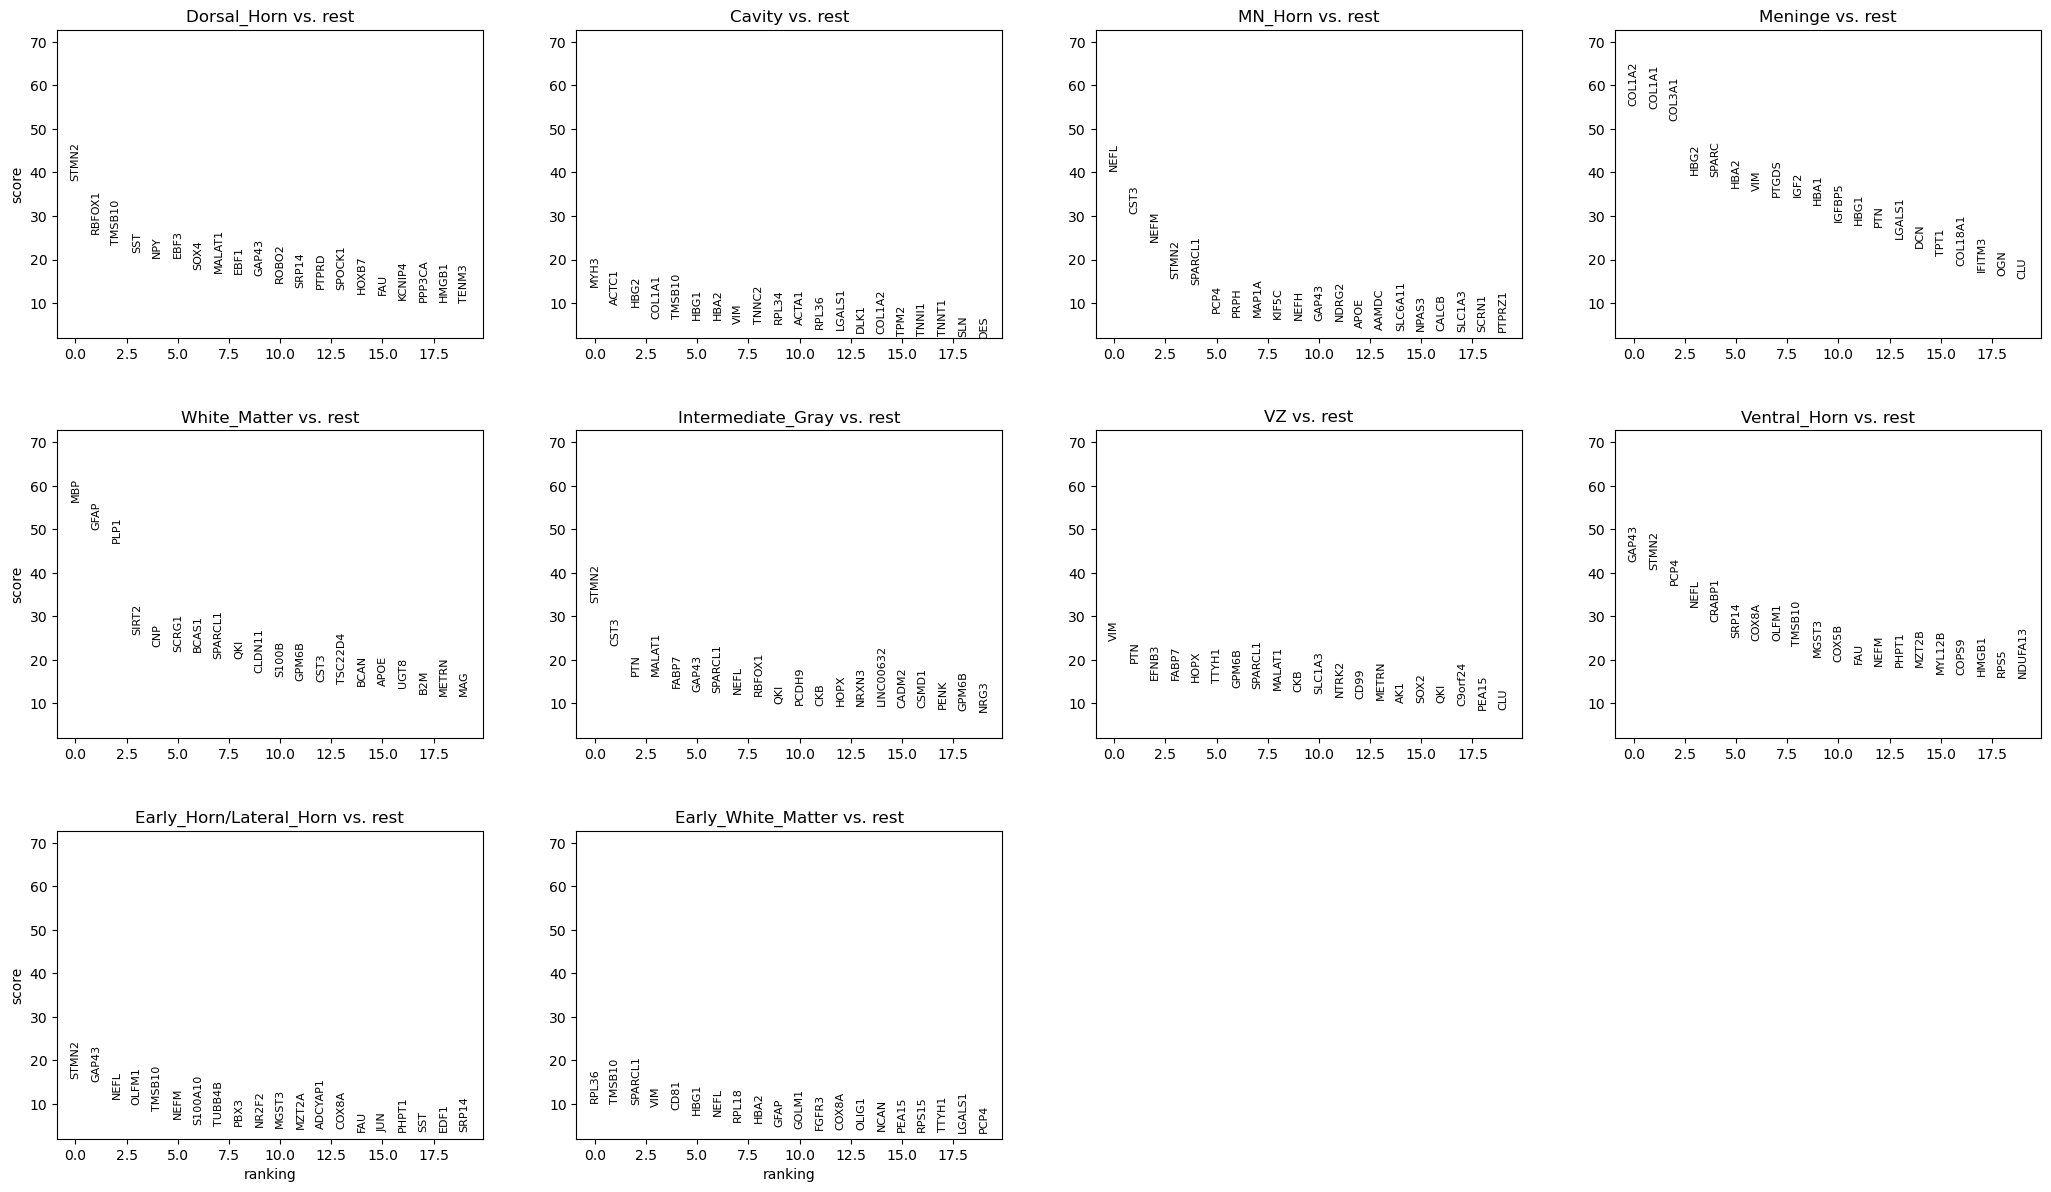

In [50]:
# Plot a summary figure showing top 25 DE genes per group
sc.pl.rank_genes_groups(adata, n_genes=20)

In [51]:
marker_niche = sc.get.rank_genes_groups_df(adata, group=None, key = 'rank_genes_groups', log2fc_min =0.25, pval_cutoff=0.05)

In [52]:
marker_niche.to_csv(f"{result_folder_path}/marker_niche.csv", index=False)

In [53]:
marker_niche

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Dorsal_Horn,STMN2,38.088661,2.421237,0.000000e+00,0.000000e+00
1,Dorsal_Horn,RBFOX1,26.027870,2.206044,2.395824e-149,9.572513e-146
2,Dorsal_Horn,TMSB10,23.479050,1.435169,6.677732e-122,1.778725e-118
3,Dorsal_Horn,SST,21.486166,2.430249,2.097293e-102,3.351894e-99
4,Dorsal_Horn,NPY,20.559904,3.920345,6.275639e-94,6.268579e-91
...,...,...,...,...,...,...
1770,Early_White_Matter,GOLM1,4.416725,0.987462,1.002076e-05,4.003795e-03
1771,Early_White_Matter,FGFR3,4.179512,1.954556,2.921358e-05,1.014981e-02
1772,Early_White_Matter,COX8A,4.161685,0.402209,3.159084e-05,1.025652e-02
1773,Early_White_Matter,OLIG1,4.143092,1.115430,3.426549e-05,1.053137e-02


#### 4.3.7 cell denstiy

"Dorsal_Horn",
"Intermediate_Gray",
"Ventral_Horn",
"Early_Horn/Lateral_Horn",
"MN_Horn",
"Early_White_Matter",
"White_Matter",
"VZ",
"Meninge",
"Cavity"

In [ ]:
file_path = f"{result_folder_path}/{dataset}_analysis.h5ad"
adata = sc.read_h5ad(file_path)

In [ ]:
adata.obs

,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,cell,x,y,batch,latent_leiden_0.3,Add-on_31_GP,...,VSTM1_ligand_receptor_target_gene_GP_source_score,VSTM1_ligand_receptor_target_gene_GP_target_score,LGALS8_ligand_receptor_GP_source_score,LGALS8_ligand_receptor_GP_target_score,Iron_metabolite_enzyme_sensor_GP_source_score,Iron_metabolite_enzyme_sensor_GP_target_score,13-cis-Retinoic acid_metabolite_enzyme_sensor_GP_source_score,13-cis-Retinoic acid_metabolite_enzyme_sensor_GP_target_score,SEMA7A_combined_GP_source_score,SEMA7A_combined_GP_target_score
GW7:4470_6510,1069.0,613,1069.0,613,GW7:4470_6510,4470.0,6510.0,gw6,8,3.316699,...,0.0,0.000000,0.0,0.0,0.000268,0.00000,0.0,0.0,0.0,0.000033
GW7:4680_6420,999.0,612,999.0,612,GW7:4680_6420,4680.0,6420.0,gw6,8,3.206848,...,0.0,0.000328,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000026
GW7:5280_5610,972.0,609,972.0,609,GW7:5280_5610,5280.0,5610.0,gw6,8,2.840173,...,0.0,0.000353,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000
GW7:4890_5580,1120.0,764,1120.0,764,GW7:4890_5580,4890.0,5580.0,gw6,6,0.056684,...,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000637
GW7:5190_6510,859.0,577,859.0,577,GW7:5190_6510,5190.0,6510.0,gw6,8,1.019332,...,0.0,0.000661,0.0,0.0,0.000000,0.00123,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GW17:14550_23100,2.0,1,2.0,1,GW17:14550_23100,14550.0,23100.0,gw17-1,1,-2.469773,...,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000
GW17:14580_23100,1.0,1,1.0,1,GW17:14580_23100,14580.0,23100.0,gw17-1,1,-0.777751,...,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000
GW17:13980_23010,2.0,1,2.0,1,GW17:13980_23010,13980.0,23010.0,gw17-1,1,-1.988651,...,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000
GW17:15240_17130,2.0,1,2.0,1,GW17:15240_17130,15240.0,17130.0,gw17-1,1,-1.671806,...,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000


In [25]:
selected_cells = adata.obs.loc[
    (adata.obs['batch'] == 'gw12') & 
    (adata.obs['niche'] == 'MN_Horn'),
    'nCount_Spatial'
]

total_nCount = selected_cells.sum()
num_cells = len(selected_cells)
density = total_nCount / num_cells
density

622.2451317296678

In [36]:
# Get all unique niche values
unique_niches = adata.obs['niche'].unique().to_list()

# Dictionary to store results
niche_density_dict = {}

for niche in unique_niches:
    # Filter cells that meet criteria
    selected_cells = adata.obs.loc[
        (adata.obs['batch'] == 'gw12') & 
        (adata.obs['niche'] == niche),
        'nCount_Spatial'
    ]
    
    # Compute density (mean value)
    if len(selected_cells) > 0:  # Avoid division by zero
        density = selected_cells.mean()
    else:
        density = 0  # or np.nan
    
    # Store result
    niche_density_dict[niche] = density

# View results
niche_density_dict

{'Early_Horn/Lateral_Horn': 576.9358974358975,
 'VZ': 726.7612687813022,
 'Early_White_Matter': 354.78813056379823,
 'Dorsal_Horn': 653.9202256244964,
 'Meninge': 397.1087202718007,
 'Cavity': 235.06776859504131,
 'Ventral_Horn': 812.9104820198929,
 'MN_Horn': 622.2451317296678,
 'Intermediate_Gray': 843.4352678571429,
 'White_Matter': 339.0}

In [38]:
import pandas as pd

# Filter batches of interest (e.g., gw12 and gw16)
selected_batches = ['gw12', 'gw16']
exclude_niches = ['Early_Horn/Lateral_Horn']

filtered_data = adata.obs[
    (adata.obs['batch'].isin(selected_batches)) & 
    (~adata.obs['niche'].isin(exclude_niches))  # Key: exclude specified niches
]

# Compute mean nCount_Spatial for each niche-batch combination
density_matrix = pd.pivot_table(
    filtered_data,
    index='niche',       # Rows: niche
    columns='batch',     # Columns: batch
    values='nCount_Spatial',  # Values: nCount_Spatial
    aggfunc='mean',      # Compute mean
    fill_value=0         # Fill missing values with 0 (optional: np.nan)
)

density_matrix

batch,gw12,gw16
niche,,
Dorsal_Horn,653.920226,754.345189
Cavity,235.067769,291.576654
MN_Horn,622.245132,497.040011
Meninge,397.108720,473.820205
White_Matter,339.000000,575.702800
Intermediate_Gray,843.435268,821.489339
VZ,726.761269,769.681818
Ventral_Horn,812.910482,953.040000
Early_White_Matter,354.788131,421.348231


In [45]:
import pandas as pd

# 1. Filter data and compute the original matrix
selected_batches = ['gw12', 'gw16']
exclude_niches = ['Early_Horn', 'Lateral_Horn']  # Note: use a list to separate multiple values

filtered_data = adata.obs[
    (adata.obs['batch'].isin(selected_batches)) & 
    (~adata.obs['niche'].isin(exclude_niches))
]

density_matrix = pd.pivot_table(
    filtered_data,
    index='niche',
    columns='batch',
    values='nCount_Spatial',
    aggfunc='mean',
    fill_value=0
)

# 2. Compute merged density of Ventral_Horn + Intermediate_Gray
target_niches = ['Ventral_Horn', 'Intermediate_Gray']
merged_density = filtered_data[
    filtered_data['niche'].isin(target_niches)
].groupby('batch')['nCount_Spatial'].mean()  # Group by batch and compute mean

# 3. Add merged result to the original matrix
density_matrix.loc['Ventral_Horn+Intermediate_Gray'] = merged_density

# View results
density_matrix

batch,gw12,gw16
niche,,
Dorsal_Horn,653.920226,754.345189
Cavity,235.067769,291.576654
MN_Horn,622.245132,497.040011
Meninge,397.108720,473.820205
White_Matter,339.000000,575.702800
Intermediate_Gray,843.435268,821.489339
VZ,726.761269,769.681818
Ventral_Horn,812.910482,953.040000
Early_Horn/Lateral_Horn,576.935897,1338.731034


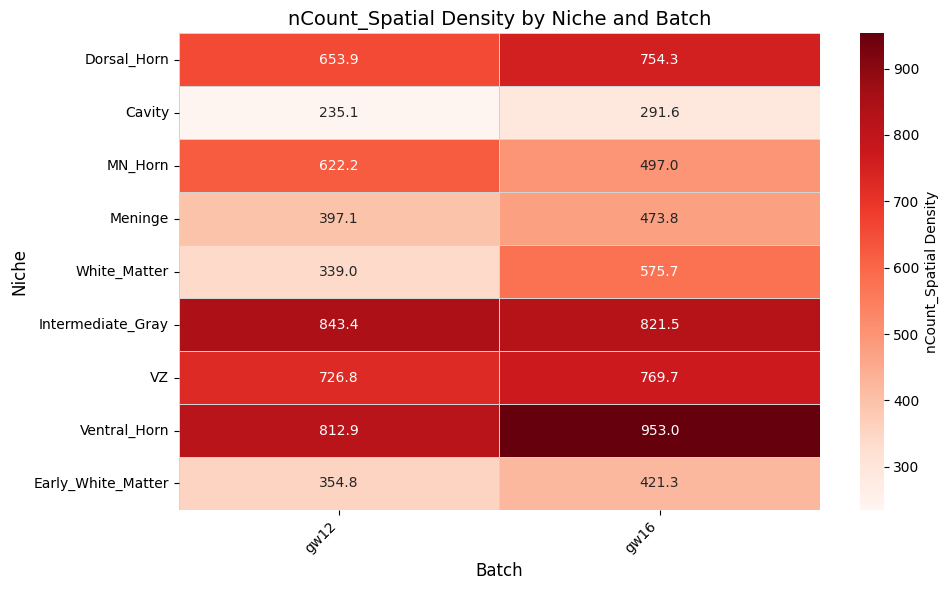

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(10, 6))

# Plot heatmap
heatmap = sns.heatmap(
    density_matrix,            # Data matrix
    annot=True,                # Show values in cells
    fmt=".1f",                # Number format (one decimal place)
    cmap="Reds",            # Colormap
    linewidths=0.5,           # Cell border width
    linecolor="lightgray",    # Cell border color
    cbar_kws={"label": "nCount_Spatial Density"}  # Colorbar label
)

# Add title and axis labels
plt.title("nCount_Spatial Density by Niche and Batch", fontsize=14)
plt.xlabel("Batch", fontsize=12)
plt.ylabel("Niche", fontsize=12)

# Rotate x-axis labels
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha="right")

# Show figure
plt.tight_layout()  # Prevent label clipping
plt.show()

In [44]:
density_matrix

batch,gw12,gw16
niche,,
Dorsal_Horn,653.920226,754.345189
Cavity,235.067769,291.576654
MN_Horn,622.245132,497.040011
Meninge,397.108720,473.820205
White_Matter,339.000000,575.702800
Intermediate_Gray,843.435268,821.489339
VZ,726.761269,769.681818
Ventral_Horn,812.910482,953.040000
Early_White_Matter,354.788131,421.348231


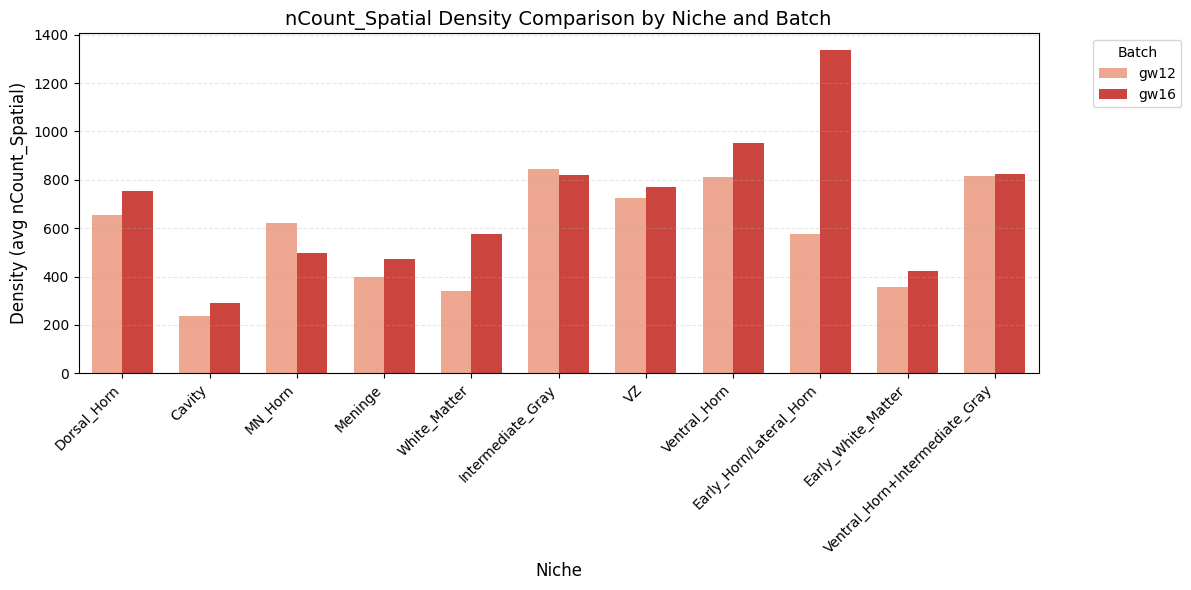

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume density_matrix is already available (rows: niche, columns: batch)
# If not yet computed, run the previous steps first:
# density_matrix = pd.pivot_table(...)

# 1. Convert matrix to long format (for seaborn plotting)
df_plot = density_matrix.reset_index().melt(
    id_vars='niche', 
    var_name='batch', 
    value_name='density'
)

# 2. Plot grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='niche',
    y='density',
    hue='batch',      # Group by batch
    palette='Reds',  # Use red palette (consistent with heatmap)
    width=0.7,       # Bar width
    errwidth=1       # Error bar width
)

# 3. Beautify the figure
plt.title("nCount_Spatial Density Comparison by Niche and Batch", fontsize=14)
plt.xlabel("Niche", fontsize=12)
plt.ylabel("Density (avg nCount_Spatial)", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.legend(title='Batch', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend
plt.grid(axis='y', linestyle='--', alpha=0.3)  # Add horizontal grid lines
plt.tight_layout()
plt.show()

In [26]:
selected_cells = adata.obs.loc[
    (adata.obs['batch'] == 'gw16') & 
    (adata.obs['niche'] == 'MN_Horn'),
    'nCount_Spatial'
]

total_nCount = selected_cells.sum()
num_cells = len(selected_cells)
density = total_nCount / num_cells
density

497.04001111419836

In [11]:
total_count = adata.obs.loc[
    (adata.obs['batch'] == 'gw12') & 
    (adata.obs['niche'] == 'MN_Horn'),
    'nCount_Spatial'
].sum()
total_count

543220.0

In [12]:
total_count = adata.obs.loc[
    (adata.obs['batch'] == 'gw16') & 
    (adata.obs['niche'] == 'MN_Horn'),
    'nCount_Spatial'
].sum()
total_count

1788847.0

In [15]:
# Filter qualifying cells and compute total nCount_Spatial
total_count = adata.obs.loc[
    (adata.obs['batch'] == 'gw12') & 
    ((adata.obs['niche'] == 'Ventral_Horn') | (adata.obs['niche'] == 'Intermediate_Gray')),
    'nCount_Spatial'
].sum()

total_count

2502807.0

In [23]:
# Filter qualifying cells and compute total nCount_Spatial
total_count = adata.obs.loc[
    (adata.obs['batch'] == 'gw12') & 
    ((adata.obs['niche'] == 'Dorsal_Horn')),
    'nCount_Spatial'
].sum()

total_count

1623030.0

In [24]:
total_count = adata.obs.loc[
    (adata.obs['batch'] == 'gw16') & 
    (adata.obs['niche'] == 'Dorsal_Horn'),
    'nCount_Spatial'
].sum()
total_count

2014856.0

# Save Results

In [206]:
model_folder_path

'../../artifacts/stereo_seq_spinal_cord_gwall/models/single_sample/27052025_044245'

In [207]:
# Save trained model
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="analysis.h5ad")

In [ ]:
model.load

In [208]:
# Log normalize counts for cellxgene server
sc.pp.normalize_total(model.adata, target_sum=1e4)
sc.pp.log1p(model.adata)

# Store gp summary in adata
gp_summary = model.get_gp_summary()
for col in gp_summary.columns:
    gp_summary[col] = gp_summary[col].astype(str)
model.adata.uns["nichecompass_gp_summary"] = gp_summary

model.adata.write(f"{result_folder_path}/{dataset}_analysis.h5ad")

In [226]:
meta = ['nCount_Spatial','nFeature_Spatial','cell','x','y','batch','niche']
model.adata.obs[meta].to_csv(f"{result_folder_path}/meta.csv", index=True)